# End-to-End NLP Resume–Job Matching & Ranking System

### Project Overview

This project builds an end-to-end NLP system for matching resumes
with job descriptions and ranking the most relevant candidates.

### Pipeline

Resume / Job Data
→ Text Processing
→ Sentence Embeddings
→ Semantic Retrieval
→ Feature Engineering
→ Learning-to-Rank
→ Top-K Candidates
→ Explainability
→ LLM-Based Explanation

### Final Model

Logistic Regression V2

### Evaluation Metrics

- Precision@10
- Recall@10
- NDCG@10
- MRR@10
- MAP@10

## 1. Imports & Setup

In [1]:
!pip install sentence-transformers pdfplumber fpdf2 datasets scikit-learn pandas -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = "/content/drive/MyDrive/resume-matcher"
os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH)

folders = ["data/raw", "data/processed", "data/pdfs", "src", "models"]
for f in folders:
    os.makedirs(f, exist_ok=True)
print("Done ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done ✅


## 2. Dataset Loading

In [3]:
import pandas as pd

base_url = "https://huggingface.co/datasets/michaelozon/candidate-matching-synthetic/resolve/main/"

df_resumes = pd.read_parquet(base_url + "resumes/train-00000-of-00001.parquet")
df_jobs = pd.read_parquet(base_url + "jobs/train-00000-of-00001.parquet")
df_matches = pd.read_parquet(base_url + "matches/train-00000-of-00001.parquet")

#
df_resumes.to_csv("data/raw/resumes.csv", index=False)
df_jobs.to_csv("data/raw/jobs.csv", index=False)
df_matches.to_csv("data/raw/matches.csv", index=False)

print(f"Resumes: {len(df_resumes)}")
print(f"Jobs: {len(df_jobs)}")
print(f"Matches: {len(df_matches)}")

Resumes: 10000
Jobs: 2500
Matches: 2500


## 3. Data Exploration

In [4]:
df_resumes.head()

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...
3,R_000003,Data Analyst,Junior,0,Healthcare,BSc,"[Excel, A/B Testing, Tableau, Pandas, Power BI...",Data Analyst with 0 years of experience in Hea...,[Delivered results using structured workflows ...
4,R_000004,BI Analyst,Junior,0,Gaming,BA,"[Statistics, SQL, Power BI, Pandas, Excel]",BI Analyst with 0 years of experience in Gaming.,[Delivered results using structured workflows ...


In [5]:
df_resumes.head()

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...
3,R_000003,Data Analyst,Junior,0,Healthcare,BSc,"[Excel, A/B Testing, Tableau, Pandas, Power BI...",Data Analyst with 0 years of experience in Hea...,[Delivered results using structured workflows ...
4,R_000004,BI Analyst,Junior,0,Gaming,BA,"[Statistics, SQL, Power BI, Pandas, Excel]",BI Analyst with 0 years of experience in Gaming.,[Delivered results using structured workflows ...


In [6]:
df_matches.head()

,job_id,relevant_resume_ids
0,J_000000,"[R_000915, R_003468, R_003641, R_003326, R_008..."
1,J_000001,"[R_003953, R_009866, R_009933, R_009826, R_007..."
2,J_000002,"[R_001833, R_005742, R_001158, R_000978, R_007..."
3,J_000003,"[R_002054, R_008377, R_003385, R_001576, R_006..."
4,J_000004,"[R_002908, R_003365, R_008335, R_005987, R_006..."


## 4. Text Processing

In [7]:
import numpy as np

# ناخد عينة 1000 سيفي بس (مش الـ 10000 كلهم) - كفاية جداً للمشروع
np.random.seed(42)
df_resumes_sample = df_resumes.sample(n=2000, random_state=42).reset_index(drop=True)

# ناخد 100 وظيفة بس
df_jobs_sample = df_jobs.sample(n=150, random_state=42).reset_index(drop=True)

# نفلتر الـ matches عشان تبقى متوافقة مع العينة اللي اخترناها
valid_job_ids = set(df_jobs_sample['job_id'])
df_matches_sample = df_matches[df_matches['job_id'].isin(valid_job_ids)].reset_index(drop=True)

# نفلتر كمان الـ relevant_resume_ids جوه matches عشان تبقى موجودة في عينة الريزيوميهات
valid_resume_ids = set(df_resumes_sample['resume_id'])
df_matches_sample['relevant_resume_ids'] = df_matches_sample['relevant_resume_ids'].apply(
    lambda ids: [i for i in ids if i in valid_resume_ids]
)

# نحفظهم كعينة العمل الأساسية
df_resumes_sample.to_csv("data/processed/resumes_sample.csv", index=False)
df_jobs_sample.to_csv("data/processed/jobs_sample.csv", index=False)
df_matches_sample.to_csv("data/processed/matches_sample.csv", index=False)

print(f"Resumes sample: {len(df_resumes_sample)}")
print(f"Jobs sample: {len(df_jobs_sample)}")
print(f"Matches sample: {len(df_matches_sample)}")
print(f"Average number of matches per job: {df_matches_sample['relevant_resume_ids'].apply(len).mean():.1f}")

Resumes sample: 2000
Jobs sample: 150
Matches sample: 150
Average number of matches per job: 5.8


In [8]:
def resume_to_text(row):
    return (
        f"{row['role']} with {row['years_experience']} years of experience "
        f"in {row['industry']}. Seniority: {row['seniority']}. "
        f"Education: {row['education']}. "
        f"Skills: {', '.join(row['skills'])}. "
        f"{row['summary']}"
    )

def job_to_text(row):
    return (
        f"{row['job_title']} ({row['seniority']} level) in {row['industry']}. "
        f"Must-have skills: {', '.join(row['must_have_skills'])}. "
        f"Nice-to-have skills: {', '.join(row['nice_to_have_skills'])}. "
        f"{row['description']}"
    )

df_resumes_sample['text'] = df_resumes_sample.apply(resume_to_text, axis=1)
df_jobs_sample['text'] = df_jobs_sample.apply(job_to_text, axis=1)



In [9]:
df_resumes_sample['text'].iloc[0]

'Backend Engineer with 2 years of experience in EdTech. Seniority: Junior. Education: BA. Skills: Python, Unit Testing, OOP, Java, Docker. Backend Engineer with 2 years of experience in EdTech.'

In [10]:
df_jobs_sample['text'].iloc[0]

'Content Marketer (Mid level) in Healthcare. Must-have skills: Content Marketing, Copywriting, A/B Testing, Email Marketing, SEO. Nice-to-have skills: Marketing Analytics. We are hiring a Content Marketer to support teams in Healthcare.'

In [11]:
# !pip install -U Pillow -q

## 5. Semantic Embeddings

In [12]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

resume_embeddings = model.encode(
    df_resumes_sample["text"].tolist(),
    show_progress_bar=True,
    batch_size= 32
)

job_embeddings = model.encode(
    df_jobs_sample['text'].tolist(),
    show_progress_bar= True,
    batch_size= 32
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

In [13]:

print(f"Resume embeddings shape: {resume_embeddings.shape}")
print(f"Job embeddings shape: {job_embeddings.shape}")

Resume embeddings shape: (2000, 384)
Job embeddings shape: (150, 384)


## 6. Semantic Retrieval

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

similarity_matrix = cosine_similarity(
    job_embeddings,
    resume_embeddings
)

In [15]:
print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (150, 2000)


In [16]:
job_idx = 0

scores = similarity_matrix[job_idx]

top_indices = np.argsort(scores)[::-1][:10]

ranking = pd.DataFrame({
    "rank": range(1, 11),
    "resume_index": top_indices,
    "semantic_score": scores[top_indices]
})

ranking

,rank,resume_index,semantic_score
0,1,821,0.818194
1,2,1290,0.801856
2,3,62,0.791173
3,4,1303,0.783060
4,5,292,0.737484
5,6,493,0.736428
6,7,1711,0.729258
7,8,1557,0.727148
8,9,1084,0.726839
9,10,1026,0.725958


In [17]:
print(df_resumes_sample.columns.tolist())
print("*******************************************")
print(df_jobs_sample.columns.tolist())

['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets', 'text']
*******************************************
['job_id', 'job_title', 'seniority', 'industry', 'must_have_skills', 'nice_to_have_skills', 'description', 'responsibilities', 'requirements', 'text']


In [18]:
print("Resume skills example:")
print(df_resumes_sample["skills"].iloc[0])

print("\nJob must-have skills example:")
print(df_jobs_sample["must_have_skills"].iloc[0])

print("\nJob nice-to-have skills example:")
print(df_jobs_sample["nice_to_have_skills"].iloc[0])

Resume skills example:
['Python' 'Unit Testing' 'OOP' 'Java' 'Docker']

Job must-have skills example:
['Content Marketing' 'Copywriting' 'A/B Testing' 'Email Marketing' 'SEO']

Job nice-to-have skills example:
['Marketing Analytics']


## 7. Candidate Ranking

In [19]:
import numpy as np

def skill_match_score(resume_skills, must_have_skills, nice_to_have_skills):
    # Convert to sets and normalize text
    resume = set(str(skill).strip().lower() for skill in resume_skills)
    must_have = set(str(skill).strip().lower() for skill in must_have_skills)
    nice_to_have = set(str(skill).strip().lower() for skill in nice_to_have_skills)

    # Must-have matching
    if len(must_have) > 0:
        matched_must = resume.intersection(must_have)
        must_score = len(matched_must) / len(must_have)
    else:
        matched_must = set()
        must_score = 0

    # Nice-to-have matching
    if len(nice_to_have) > 0:
        matched_nice = resume.intersection(nice_to_have)
        nice_score = len(matched_nice) / len(nice_to_have)
    else:
        matched_nice = set()
        nice_score = 0

    # Final skill score
    final_score = (0.8 * must_score) + (0.2 * nice_score)

    return {
        "skill_score": final_score,
        "must_score": must_score,
        "nice_score": nice_score,
        "matched_must": list(matched_must),
        "matched_nice": list(matched_nice),
        "missing_must": list(must_have - resume)
    }

In [20]:
resume_idx = 0
job_idx = 0

result = skill_match_score(
    df_resumes_sample.loc[resume_idx, "skills"],
    df_jobs_sample.loc[job_idx, "must_have_skills"],
    df_jobs_sample.loc[job_idx, "nice_to_have_skills"]
)

result

{'skill_score': 0.0,
 'must_score': 0.0,
 'nice_score': 0.0,
 'matched_must': [],
 'matched_nice': [],
 'missing_must': ['a/b testing',
  'seo',
  'email marketing',
  'content marketing',
  'copywriting']}

In [21]:
TOP_K = 100

top_k_indices = np.argsort(
    similarity_matrix,
    axis=1
)[:, ::-1][:, :TOP_K]

top_k_scores = np.take_along_axis(
    similarity_matrix,
    top_k_indices,
    axis=1
)

print("Top-K indices shape:", top_k_indices.shape)
print("Top-K scores shape:", top_k_scores.shape)

Top-K indices shape: (150, 100)
Top-K scores shape: (150, 100)


In [22]:
job_idx = 0

for rank, (resume_idx, score) in enumerate(
    zip(top_k_indices[job_idx], top_k_scores[job_idx]),
    start=1
):
    print(
        f"Rank {rank:3} | "
        f"Resume Index {resume_idx:4} | "
        f"Semantic Score {score:.4f}"
    )

Rank   1 | Resume Index  821 | Semantic Score 0.8182
Rank   2 | Resume Index 1290 | Semantic Score 0.8019
Rank   3 | Resume Index   62 | Semantic Score 0.7912
Rank   4 | Resume Index 1303 | Semantic Score 0.7831
Rank   5 | Resume Index  292 | Semantic Score 0.7375
Rank   6 | Resume Index  493 | Semantic Score 0.7364
Rank   7 | Resume Index 1711 | Semantic Score 0.7293
Rank   8 | Resume Index 1557 | Semantic Score 0.7271
Rank   9 | Resume Index 1084 | Semantic Score 0.7268
Rank  10 | Resume Index 1026 | Semantic Score 0.7260
Rank  11 | Resume Index   25 | Semantic Score 0.7247
Rank  12 | Resume Index 1483 | Semantic Score 0.7246
Rank  13 | Resume Index  669 | Semantic Score 0.7205
Rank  14 | Resume Index 1914 | Semantic Score 0.7201
Rank  15 | Resume Index  630 | Semantic Score 0.7196
Rank  16 | Resume Index 1403 | Semantic Score 0.7190
Rank  17 | Resume Index 1484 | Semantic Score 0.7188
Rank  18 | Resume Index 1477 | Semantic Score 0.7187
Rank  19 | Resume Index 1551 | Semantic Score 

In [23]:
job_idx = 0
resume_idx = 0

print("=" * 60)

print("JOB")
print("job_id:", df_jobs_sample.iloc[job_idx]["job_id"])
print("title:", df_jobs_sample.iloc[job_idx]["job_title"])
print("seniority:", df_jobs_sample.iloc[job_idx]["seniority"])
print("industry:", df_jobs_sample.iloc[job_idx]["industry"])
print("must-have:", df_jobs_sample.iloc[job_idx]["must_have_skills"])
print("nice-to-have:", df_jobs_sample.iloc[job_idx]["nice_to_have_skills"])

print("\n" + "=" * 60)

print("RESUME")
print("resume_id:", df_resumes_sample.iloc[resume_idx]["resume_id"])
print("role:", df_resumes_sample.iloc[resume_idx]["role"])
print("seniority:", df_resumes_sample.iloc[resume_idx]["seniority"])
print("industry:", df_resumes_sample.iloc[resume_idx]["industry"])
print("years:", df_resumes_sample.iloc[resume_idx]["years_experience"])
print("skills:", df_resumes_sample.iloc[resume_idx]["skills"])

print("\n" + "=" * 60)

print("JOB TEXT:")
print(df_jobs_sample.iloc[job_idx]["text"][:1000])

print("\n" + "=" * 60)

print("RESUME TEXT:")
print(df_resumes_sample.iloc[resume_idx]["text"][:1000])

JOB
job_id: J_001447
title: Content Marketer
seniority: Mid
industry: Healthcare
must-have: ['Content Marketing' 'Copywriting' 'A/B Testing' 'Email Marketing' 'SEO']
nice-to-have: ['Marketing Analytics']

RESUME
resume_id: R_006252
role: Backend Engineer
seniority: Junior
industry: EdTech
years: 2
skills: ['Python' 'Unit Testing' 'OOP' 'Java' 'Docker']

JOB TEXT:
Content Marketer (Mid level) in Healthcare. Must-have skills: Content Marketing, Copywriting, A/B Testing, Email Marketing, SEO. Nice-to-have skills: Marketing Analytics. We are hiring a Content Marketer to support teams in Healthcare.

RESUME TEXT:
Backend Engineer with 2 years of experience in EdTech. Seniority: Junior. Education: BA. Skills: Python, Unit Testing, OOP, Java, Docker. Backend Engineer with 2 years of experience in EdTech.


In [24]:
print("Resume embeddings shape:", resume_embeddings.shape)
print("Job embeddings shape:", job_embeddings.shape)

print("\nFirst resume embedding:")
print(resume_embeddings[0][:10])

print("\nFirst job embedding:")
print(job_embeddings[0][:10])

print("\nAre they exactly equal?")
print(np.array_equal(resume_embeddings[0], job_embeddings[0]))

print("\nCosine similarity:")
print(cosine_similarity(
    resume_embeddings[0].reshape(1, -1),
    job_embeddings[0].reshape(1, -1)
)[0][0])

Resume embeddings shape: (2000, 384)
Job embeddings shape: (150, 384)

First resume embedding:
[-0.04832932  0.00290706  0.10474876  0.00153327 -0.06317236 -0.11471015
 -0.07475664  0.00807169 -0.07515445 -0.06858371]

First job embedding:
[-0.04226732 -0.02650031 -0.0165093  -0.0187191   0.00576203  0.01289125
  0.00677796  0.06444903 -0.01678673 -0.02408243]

Are they exactly equal?
False

Cosine similarity:
0.33524233


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    job_embeddings,
    resume_embeddings
)

print("Similarity matrix shape:", similarity_matrix.shape)


Similarity matrix shape: (150, 2000)


In [26]:
TOP_K = 100

top_k_indices = np.argsort(
    similarity_matrix,
    axis=1
)[:, ::-1][:, :TOP_K]

top_k_scores = np.take_along_axis(
    similarity_matrix,
    top_k_indices,
    axis=1
)

print("Top-K indices shape:", top_k_indices.shape)
print("Top-K scores shape:", top_k_scores.shape)

Top-K indices shape: (150, 100)
Top-K scores shape: (150, 100)


In [27]:
job_idx = 0

for rank, (resume_idx, score) in enumerate(
    zip(top_k_indices[job_idx], top_k_scores[job_idx]),
    start=1
):
    print(
        f"Rank {rank:3} | "
        f"Resume Index {resume_idx:4} | "
        f"Semantic Score {score:.4f}"
    )

Rank   1 | Resume Index  821 | Semantic Score 0.8182
Rank   2 | Resume Index 1290 | Semantic Score 0.8019
Rank   3 | Resume Index   62 | Semantic Score 0.7912
Rank   4 | Resume Index 1303 | Semantic Score 0.7831
Rank   5 | Resume Index  292 | Semantic Score 0.7375
Rank   6 | Resume Index  493 | Semantic Score 0.7364
Rank   7 | Resume Index 1711 | Semantic Score 0.7293
Rank   8 | Resume Index 1557 | Semantic Score 0.7271
Rank   9 | Resume Index 1084 | Semantic Score 0.7268
Rank  10 | Resume Index 1026 | Semantic Score 0.7260
Rank  11 | Resume Index   25 | Semantic Score 0.7247
Rank  12 | Resume Index 1483 | Semantic Score 0.7246
Rank  13 | Resume Index  669 | Semantic Score 0.7205
Rank  14 | Resume Index 1914 | Semantic Score 0.7201
Rank  15 | Resume Index  630 | Semantic Score 0.7196
Rank  16 | Resume Index 1403 | Semantic Score 0.7190
Rank  17 | Resume Index 1484 | Semantic Score 0.7188
Rank  18 | Resume Index 1477 | Semantic Score 0.7187
Rank  19 | Resume Index 1551 | Semantic Score 

In [28]:
import re


def extract_required_experience(text):
    text = str(text).lower()

    patterns = [
        r'(\d+)\+?\s*years?\s+of\s+experience',
        r'minimum\s+of\s+(\d+)\s*years?',
        r'at\s+least\s+(\d+)\s*years?',
        r'(\d+)\+?\s*years?'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return int(match.group(1))

    return 0

In [29]:
def experience_match_score(candidate_years, required_years):

    candidate_years = float(candidate_years)
    required_years = float(required_years)

    if required_years == 0:
        return 1.0

    if candidate_years >= required_years:
        return 1.0

    return candidate_years / required_years

In [30]:
job_idx = 0

job_requirements = df_jobs_sample.iloc[job_idx]["requirements"]

required_years = extract_required_experience(job_requirements)

print("Job:", df_jobs_sample.iloc[job_idx]["job_title"])
print("Requirements:", job_requirements)
print("Required experience:", required_years)

Job: Content Marketer
Requirements: ['Relevant experience and ability to learn quickly'
 'Strong communication and ownership mindset'
 'Comfort working with tools, data, and cross-functional teams']
Required experience: 0


In [31]:
job_idx = 0

job_requirements = df_jobs_sample.iloc[job_idx]["requirements"]

required_years = extract_required_experience(job_requirements)

print("Job:", df_jobs_sample.iloc[job_idx]["job_title"])
print("Requirements:", job_requirements)
print("Required experience:", required_years)

Job: Content Marketer
Requirements: ['Relevant experience and ability to learn quickly'
 'Strong communication and ownership mindset'
 'Comfort working with tools, data, and cross-functional teams']
Required experience: 0


In [32]:
print(df_jobs_sample.iloc[0])

job_id                                                          J_001447
job_title                                               Content Marketer
seniority                                                            Mid
industry                                                      Healthcare
must_have_skills       [Content Marketing, Copywriting, A/B Testing, ...
nice_to_have_skills                                [Marketing Analytics]
description            We are hiring a Content Marketer to support te...
responsibilities       [Deliver high-quality work aligned with goals ...
requirements           [Relevant experience and ability to learn quic...
text                   Content Marketer (Mid level) in Healthcare. Mu...
Name: 0, dtype: object


In [33]:
resume_idx = top_k_indices[0][0]

print(df_resumes_sample.iloc[resume_idx])

resume_id                                                      R_005983
role                                                   Content Marketer
seniority                                                        Senior
years_experience                                                      9
industry                                                     Healthcare
education                                                            BA
skills                [Content Marketing, Landing Pages, A/B Testing...
summary               Content Marketer with 9 years of experience in...
experience_bullets    [Delivered results using structured workflows ...
text                  Content Marketer with 9 years of experience in...
Name: 821, dtype: object


In [34]:
job_idx = 0
resume_idx = top_k_indices[job_idx][0]

result = skill_match_score(
    df_resumes_sample.iloc[resume_idx]["skills"],
    df_jobs_sample.iloc[job_idx]["must_have_skills"],
    df_jobs_sample.iloc[job_idx]["nice_to_have_skills"]
)

print("Resume:", df_resumes_sample.iloc[resume_idx]["resume_id"])
print("Job:", df_jobs_sample.iloc[job_idx]["job_id"])

print("\nSkill Score:", result["skill_score"])
print("Must-have Score:", result["must_score"])
print("Nice-to-have Score:", result["nice_score"])

print("\nMatched Must-have:")
print(result["matched_must"])

print("\nMatched Nice-to-have:")
print(result["matched_nice"])

print("\nMissing Must-have:")
print(result["missing_must"])

Resume: R_005983
Job: J_001447

Skill Score: 0.8400000000000001
Must-have Score: 0.8
Nice-to-have Score: 1.0

Matched Must-have:
['content marketing', 'copywriting', 'a/b testing', 'email marketing']

Matched Nice-to-have:
['marketing analytics']

Missing Must-have:
['seo']


In [35]:
print("Resume seniority values:")
print(df_resumes_sample["seniority"].value_counts())

print("\nJob seniority values:")
print(df_jobs_sample["seniority"].value_counts())

Resume seniority values:
seniority
Mid       685
Junior    663
Senior    652
Name: count, dtype: int64

Job seniority values:
seniority
Junior    55
Mid       53
Senior    42
Name: count, dtype: int64


In [36]:
# test_resume = df_resumes_sample.iloc[0]["text"]
# test_job = df_jobs_sample.iloc[0]["text"]

# test_embeddings = model.encode(
#     [test_resume, test_job],
#     normalize_embeddings=True
# )

# test_similarity = cosine_similarity(
#     [test_embeddings[0]],
#     [test_embeddings[1]]
# )[0][0]

# print("Independent similarity:", test_similarity)

In [38]:
def seniority_match_score(candidate_seniority, job_seniority):

    candidate = str(candidate_seniority).strip().lower()
    job = str(job_seniority).strip().lower()

    levels = {
        "junior": 1,
        "mid": 2,
        "senior": 3
    }

    if candidate not in levels or job not in levels:
        return 0.0

    difference = abs(levels[candidate] - levels[job])

    if difference == 0:
        return 1.0
    elif difference == 1:
        return 0.5
    else:
        return 0.0

In [39]:
job_idx = 0
resume_idx = top_k_indices[job_idx][0]

candidate_seniority = df_resumes_sample.iloc[resume_idx]["seniority"]
job_seniority = df_jobs_sample.iloc[job_idx]["seniority"]

score = seniority_match_score(
    candidate_seniority,
    job_seniority
)

print("Candidate seniority:", candidate_seniority)
print("Job seniority:", job_seniority)
print("Seniority Match:", score)

Candidate seniority: Senior
Job seniority: Mid
Seniority Match: 0.5


In [40]:
def industry_match_score(candidate_industry, job_industry):

    candidate = str(candidate_industry).strip().lower()
    job = str(job_industry).strip().lower()

    if candidate == job:
        return 1.0
    else:
        return 0.0

In [41]:
job_idx = 0
resume_idx = top_k_indices[job_idx][0]

candidate_industry = df_resumes_sample.iloc[resume_idx]["industry"]
job_industry = df_jobs_sample.iloc[job_idx]["industry"]

score = industry_match_score(
    candidate_industry,
    job_industry
)

print("Candidate industry:", candidate_industry)
print("Job industry:", job_industry)
print("Industry Match:", score)

Candidate industry: Healthcare
Job industry: Healthcare
Industry Match: 1.0


In [42]:
print("Resume experience statistics:")
print(df_resumes_sample["years_experience"].describe())

Resume experience statistics:
count    2000.0000
mean        4.6315
std         3.6357
min         0.0000
25%         2.0000
50%         4.0000
75%         7.0000
max        12.0000
Name: years_experience, dtype: float64


In [43]:
def experience_match_score(candidate_years, job_seniority):

    candidate_years = float(candidate_years)
    job_seniority = str(job_seniority).strip().lower()

    if job_seniority == "junior":
        if candidate_years <= 2:
            return 1.0
        elif candidate_years <= 5:
            return 0.5
        else:
            return 0.0

    elif job_seniority == "mid":
        if 3 <= candidate_years <= 6:
            return 1.0
        elif 2 <= candidate_years < 3 or 7 <= candidate_years <= 9:
            return 0.5
        else:
            return 0.0

    elif job_seniority == "senior":
        if candidate_years >= 7:
            return 1.0
        elif candidate_years >= 5:
            return 0.5
        else:
            return 0.0

    return 0.0

In [44]:
job_idx = 0
resume_idx = top_k_indices[job_idx][0]

candidate_years = df_resumes_sample.iloc[resume_idx]["years_experience"]
job_seniority = df_jobs_sample.iloc[job_idx]["seniority"]

score = experience_match_score(
    candidate_years,
    job_seniority
)

print("Candidate experience:", candidate_years)
print("Job seniority:", job_seniority)
print("Experience Match:", score)

Candidate experience: 9
Job seniority: Mid
Experience Match: 0.5


In [45]:
semantic_score = similarity_matrix[job_idx, resume_idx]

skill_score = result["skill_score"]

experience_score = experience_match_score(
    df_resumes_sample.iloc[resume_idx]["years_experience"],
    df_jobs_sample.iloc[job_idx]["seniority"]
)

seniority_score = seniority_match_score(
    df_resumes_sample.iloc[resume_idx]["seniority"],
    df_jobs_sample.iloc[job_idx]["seniority"]
)

industry_score = industry_match_score(
    df_resumes_sample.iloc[resume_idx]["industry"],
    df_jobs_sample.iloc[job_idx]["industry"]
)

final_score = (
    0.50 * semantic_score +
    0.30 * skill_score +
    0.10 * experience_score +
    0.05 * seniority_score +
    0.05 * industry_score
)

print("Semantic Score:", round(semantic_score, 4))
print("Skill Score:", round(skill_score, 4))
print("Experience Score:", round(experience_score, 4))
print("Seniority Score:", round(seniority_score, 4))
print("Industry Score:", round(industry_score, 4))

print("\nFinal Hybrid Score:", round(final_score, 4))
print("Final Match %:", round(final_score * 100, 2), "%")

Semantic Score: 0.8182
Skill Score: 0.84
Experience Score: 0.5
Seniority Score: 0.5
Industry Score: 1.0

Final Hybrid Score: 0.7861
Final Match %: 78.61 %


In [46]:
def calculate_hybrid_score(job_idx, resume_idx):

    # 1. Semantic Score
    semantic_score = similarity_matrix[job_idx, resume_idx]

    # 2. Skill Score
    skill_result = skill_match_score(
        df_resumes_sample.iloc[resume_idx]["skills"],
        df_jobs_sample.iloc[job_idx]["must_have_skills"],
        df_jobs_sample.iloc[job_idx]["nice_to_have_skills"]
    )

    skill_score = skill_result["skill_score"]

    # 3. Experience Score
    experience_score = experience_match_score(
        df_resumes_sample.iloc[resume_idx]["years_experience"],
        df_jobs_sample.iloc[job_idx]["seniority"]
    )

    # 4. Seniority Score
    seniority_score = seniority_match_score(
        df_resumes_sample.iloc[resume_idx]["seniority"],
        df_jobs_sample.iloc[job_idx]["seniority"]
    )

    # 5. Industry Score
    industry_score = industry_match_score(
        df_resumes_sample.iloc[resume_idx]["industry"],
        df_jobs_sample.iloc[job_idx]["industry"]
    )

    # 6. Final Hybrid Score
    final_score = (
        0.50 * semantic_score +
        0.30 * skill_score +
        0.10 * experience_score +
        0.05 * seniority_score +
        0.05 * industry_score
    )

    return {
        "semantic_score": semantic_score,
        "skill_score": skill_score,
        "experience_score": experience_score,
        "seniority_score": seniority_score,
        "industry_score": industry_score,
        "final_score": final_score,
        "matched_must": skill_result["matched_must"],
        "matched_nice": skill_result["matched_nice"],
        "missing_must": skill_result["missing_must"]
    }

In [48]:
job_idx = 0
resume_idx = top_k_indices[job_idx][0]

result_hybrid = calculate_hybrid_score(
    job_idx,
    resume_idx
)

result_hybrid

{'semantic_score': np.float32(0.8181936),
 'skill_score': 0.8400000000000001,
 'experience_score': 0.5,
 'seniority_score': 0.5,
 'industry_score': 1.0,
 'final_score': np.float32(0.7860968),
 'matched_must': ['content marketing',
  'copywriting',
  'a/b testing',
  'email marketing'],
 'matched_nice': ['marketing analytics'],
 'missing_must': ['seo']}

In [49]:
job_idx = 0

results = []

for resume_idx in top_k_indices[job_idx]:

    result = calculate_hybrid_score(
        job_idx,
        resume_idx
    )

    results.append({
        "resume_idx": resume_idx,
        "resume_id": df_resumes_sample.iloc[resume_idx]["resume_id"],
        "role": df_resumes_sample.iloc[resume_idx]["role"],
        "seniority": df_resumes_sample.iloc[resume_idx]["seniority"],
        "industry": df_resumes_sample.iloc[resume_idx]["industry"],
        "final_score": result["final_score"],
        "semantic_score": result["semantic_score"],
        "skill_score": result["skill_score"],
        "experience_score": result["experience_score"],
        "seniority_score": result["seniority_score"],
        "industry_score": result["industry_score"]
    })

hybrid_results = pd.DataFrame(results)

hybrid_results = hybrid_results.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

hybrid_results.head(10)

,resume_idx,resume_id,role,seniority,industry,final_score,semantic_score,skill_score,experience_score,seniority_score,industry_score
0,667,R_001568,Content Marketer,Mid,SaaS,0.801070,0.702140,1.00,1.0,1.0,0.0
1,1763,R_000037,Content Marketer,Mid,SaaS,0.798462,0.696923,1.00,1.0,1.0,0.0
2,816,R_005814,Content Marketer,Mid,Cybersecurity,0.787058,0.674115,1.00,1.0,1.0,0.0
3,821,R_005983,Content Marketer,Senior,Healthcare,0.786097,0.818194,0.84,0.5,0.5,1.0
4,1405,R_000408,Performance Marketer,Junior,Healthcare,0.774364,0.698728,1.00,0.5,0.5,1.0
5,1084,R_007405,Content Marketer,Mid,Retail,0.765420,0.726839,0.84,1.0,1.0,0.0
6,425,R_008310,Content Marketer,Mid,E-commerce,0.753659,0.703319,0.84,1.0,1.0,0.0
7,1303,R_003846,Content Marketer,Mid,Healthcare,0.747530,0.783060,0.52,1.0,1.0,1.0
8,1711,R_009050,Content Marketer,Junior,Logistics,0.739629,0.729258,1.00,0.5,0.5,0.0
9,1619,R_005746,Content Marketer,Mid,Cybersecurity,0.727342,0.674684,0.80,1.0,1.0,0.0


In [50]:
top_10 = hybrid_results.head(10).copy()

top_10["match_score"] = top_10["final_score"] * 100

top_10 = top_10[
    [
        "resume_id",
        "role",
        "seniority",
        "industry",
        "match_score",
        "semantic_score",
        "skill_score",
        "experience_score",
        "seniority_score",
        "industry_score"
    ]
]

top_10

,resume_id,role,seniority,industry,match_score,semantic_score,skill_score,experience_score,seniority_score,industry_score
0,R_001568,Content Marketer,Mid,SaaS,80.106995,0.702140,1.00,1.0,1.0,0.0
1,R_000037,Content Marketer,Mid,SaaS,79.846153,0.696923,1.00,1.0,1.0,0.0
2,R_005814,Content Marketer,Mid,Cybersecurity,78.705780,0.674115,1.00,1.0,1.0,0.0
3,R_005983,Content Marketer,Senior,Healthcare,78.609680,0.818194,0.84,0.5,0.5,1.0
4,R_000408,Performance Marketer,Junior,Healthcare,77.436378,0.698728,1.00,0.5,0.5,1.0
5,R_007405,Content Marketer,Mid,Retail,76.541969,0.726839,0.84,1.0,1.0,0.0
6,R_008310,Content Marketer,Mid,E-commerce,75.365944,0.703319,0.84,1.0,1.0,0.0
7,R_003846,Content Marketer,Mid,Healthcare,74.753021,0.783060,0.52,1.0,1.0,1.0
8,R_009050,Content Marketer,Junior,Logistics,73.962906,0.729258,1.00,0.5,0.5,0.0
9,R_005746,Content Marketer,Mid,Cybersecurity,72.734215,0.674684,0.80,1.0,1.0,0.0


In [51]:
def explain_skill_match(job_idx, resume_idx):

    result = skill_match_score(
        df_resumes_sample.iloc[resume_idx]["skills"],
        df_jobs_sample.iloc[job_idx]["must_have_skills"],
        df_jobs_sample.iloc[job_idx]["nice_to_have_skills"]
    )

    return {
        "matched_must_have": result["matched_must"],
        "matched_nice_to_have": result["matched_nice"],
        "missing_must_have": result["missing_must"]
    }

In [52]:
explanation = explain_skill_match(
    job_idx=0,
    resume_idx=821
)

explanation

{'matched_must_have': ['content marketing',
  'copywriting',
  'a/b testing',
  'email marketing'],
 'matched_nice_to_have': ['marketing analytics'],
 'missing_must_have': ['seo']}

In [53]:
def explain_candidate(job_idx, resume_idx):

    result = calculate_hybrid_score(
        job_idx,
        resume_idx
    )

    resume = df_resumes_sample.iloc[resume_idx]
    job = df_jobs_sample.iloc[job_idx]

    return {
        "resume_id": resume["resume_id"],
        "role": resume["role"],
        "candidate_seniority": resume["seniority"],
        "job_seniority": job["seniority"],
        "years_experience": resume["years_experience"],
        "candidate_industry": resume["industry"],
        "job_industry": job["industry"],
        "matched_must_have": result["matched_must"],
        "matched_nice_to_have": result["matched_nice"],
        "missing_must_have": result["missing_must"],
        "semantic_score": result["semantic_score"],
        "skill_score": result["skill_score"],
        "experience_score": result["experience_score"],
        "seniority_score": result["seniority_score"],
        "industry_score": result["industry_score"],
        "final_score": result["final_score"]
    }

In [54]:
candidate_explanation = explain_candidate(
    job_idx=0,
    resume_idx=821
)

candidate_explanation

{'resume_id': 'R_005983',
 'role': 'Content Marketer',
 'candidate_seniority': 'Senior',
 'job_seniority': 'Mid',
 'years_experience': np.int64(9),
 'candidate_industry': 'Healthcare',
 'job_industry': 'Healthcare',
 'matched_must_have': ['content marketing',
  'copywriting',
  'a/b testing',
  'email marketing'],
 'matched_nice_to_have': ['marketing analytics'],
 'missing_must_have': ['seo'],
 'semantic_score': np.float32(0.8181936),
 'skill_score': 0.8400000000000001,
 'experience_score': 0.5,
 'seniority_score': 0.5,
 'industry_score': 1.0,
 'final_score': np.float32(0.7860968)}

In [55]:
def generate_explanation(job_idx, resume_idx):

    result = calculate_hybrid_score(
        job_idx,
        resume_idx
    )

    resume = df_resumes_sample.iloc[resume_idx]
    job = df_jobs_sample.iloc[job_idx]

    explanation = {
        "resume_id": resume["resume_id"],

        "skills": {
            "matched_must_have": result["matched_must"],
            "matched_nice_to_have": result["matched_nice"],
            "missing_must_have": result["missing_must"]
        },

        "experience": (
            f"Candidate has {resume['years_experience']} years of experience "
            f"for a {job['seniority']} level position."
        ),

        "seniority": (
            f"Candidate seniority: {resume['seniority']} | "
            f"Job seniority: {job['seniority']}"
        ),

        "industry": (
            f"Candidate industry: {resume['industry']} | "
            f"Job industry: {job['industry']}"
        ),

        "scores": {
            "semantic": float(result["semantic_score"]),
            "skills": float(result["skill_score"]),
            "experience": float(result["experience_score"]),
            "seniority": float(result["seniority_score"]),
            "industry": float(result["industry_score"]),
            "final": float(result["final_score"])
        }
    }

    return explanation

In [56]:
explanation = generate_explanation(
    job_idx=0,
    resume_idx=821
)

explanation

{'resume_id': 'R_005983',
 'skills': {'matched_must_have': ['content marketing',
   'copywriting',
   'a/b testing',
   'email marketing'],
  'matched_nice_to_have': ['marketing analytics'],
  'missing_must_have': ['seo']},
 'experience': 'Candidate has 9 years of experience for a Mid level position.',
 'seniority': 'Candidate seniority: Senior | Job seniority: Mid',
 'industry': 'Candidate industry: Healthcare | Job industry: Healthcare',
 'scores': {'semantic': 0.8181936144828796,
  'skills': 0.8400000000000001,
  'experience': 0.5,
  'seniority': 0.5,
  'industry': 1.0,
  'final': 0.7860968112945557}}

In [57]:
df_matches_sample.head()

,job_id,relevant_resume_ids
0,J_000043,"[R_007087, R_006271, R_004216, R_009772, R_009..."
1,J_000044,"[R_001314, R_007737, R_004513, R_001247, R_006..."
2,J_000056,"[R_004826, R_008239, R_001418, R_003412]"
3,J_000093,"[R_009170, R_008719, R_004881, R_009974, R_009..."
4,J_000111,"[R_004397, R_005333, R_004995, R_004484]"


In [58]:
df_matches_sample.columns.tolist()

['job_id', 'relevant_resume_ids']

In [59]:
df_matches_sample.head(3).to_dict("records")

[{'job_id': 'J_000043',
  'relevant_resume_ids': ['R_007087',
   'R_006271',
   'R_004216',
   'R_009772',
   'R_009351',
   'R_008703',
   'R_007763']},
 {'job_id': 'J_000044',
  'relevant_resume_ids': ['R_001314',
   'R_007737',
   'R_004513',
   'R_001247',
   'R_006621',
   'R_005111']},
 {'job_id': 'J_000056',
  'relevant_resume_ids': ['R_004826', 'R_008239', 'R_001418', 'R_003412']}]

In [60]:
ground_truth = dict(
    zip(
        df_matches_sample["job_id"],
        df_matches_sample["relevant_resume_ids"]
    )
)

ground_truth["J_000043"]

['R_007087',
 'R_006271',
 'R_004216',
 'R_009772',
 'R_009351',
 'R_008703',
 'R_007763']

In [61]:
def precision_at_k(ranked_resume_ids, relevant_resume_ids, k=10):

    top_k = ranked_resume_ids[:k]

    relevant_set = set(relevant_resume_ids)

    relevant_retrieved = sum(
        resume_id in relevant_set
        for resume_id in top_k
    )

    return relevant_retrieved / k

In [62]:
job_id = df_jobs_sample.iloc[0]["job_id"]

ranked_resume_ids = hybrid_results["resume_id"].tolist()

relevant_resume_ids = ground_truth.get(job_id, [])

precision_10 = precision_at_k(
    ranked_resume_ids,
    relevant_resume_ids,
    k=10
)

print("Job:", job_id)
print("Precision@10:", precision_10)

Job: J_001447
Precision@10: 0.1


In [63]:
relevant_in_top10 = [
    resume_id
    for resume_id in ranked_resume_ids[:10]
    if resume_id in set(relevant_resume_ids)
]

relevant_in_top10

['R_007405']

In [64]:
def recall_at_k(ranked_resume_ids, relevant_resume_ids, k=10):

    top_k = ranked_resume_ids[:k]

    relevant_set = set(relevant_resume_ids)

    relevant_retrieved = sum(
        resume_id in relevant_set
        for resume_id in top_k
    )

    if len(relevant_set) == 0:
        return 0.0

    return relevant_retrieved / len(relevant_set)

In [65]:
recall_10 = recall_at_k(
    ranked_resume_ids,
    relevant_resume_ids,
    k=10
)

print("Recall@10:", recall_10)

Recall@10: 1.0


In [67]:
evaluation_results = []

for job_idx in range(len(df_jobs_sample)):

    job_id = df_jobs_sample.iloc[job_idx]["job_id"]

    if job_id not in ground_truth:
        continue

    # ترتيب الـ Top 100 بالـ Hybrid Score
    results = []

    for resume_idx in top_k_indices[job_idx]:

        result = calculate_hybrid_score(
            job_idx,
            resume_idx
        )

        results.append({
            "resume_id": df_resumes_sample.iloc[resume_idx]["resume_id"],
            "final_score": result["final_score"]
        })

    results_df = pd.DataFrame(results).sort_values(
        "final_score",
        ascending=False
    )

    ranked_ids = results_df["resume_id"].tolist()

    relevant_ids = ground_truth[job_id]

    precision = precision_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    recall = recall_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    evaluation_results.append({
        "job_id": job_id,
        "precision_at_10": precision,
        "recall_at_10": recall
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.head()

,job_id,precision_at_10,recall_at_10
0,J_001447,0.1,1.000000
1,J_001114,0.0,0.000000
2,J_001064,0.2,0.222222
3,J_002287,0.0,0.000000
4,J_001537,0.0,0.000000


In [68]:
mean_precision_at_10 = evaluation_df["precision_at_10"].mean()
mean_recall_at_10 = evaluation_df["recall_at_10"].mean()

print("Mean Precision@10:", mean_precision_at_10)
print("Mean Recall@10:", mean_recall_at_10)


Mean Precision@10: 0.036000000000000004
Mean Recall@10: 0.06214357864357864


In [69]:
print("Evaluated Jobs:", len(evaluation_df))
print("Total Jobs:", len(df_jobs_sample))

Evaluated Jobs: 150
Total Jobs: 150


In [70]:
semantic_evaluation_results = []

for job_idx in range(len(df_jobs_sample)):

    job_id = df_jobs_sample.iloc[job_idx]["job_id"]

    if job_id not in ground_truth:
        continue

    # ترتيب المرشحين بالـ Semantic Score فقط
    ranked_indices = top_k_indices[job_idx]

    ranked_ids = [
        df_resumes_sample.iloc[idx]["resume_id"]
        for idx in ranked_indices
    ]

    relevant_ids = ground_truth[job_id]

    precision = precision_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    recall = recall_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    semantic_evaluation_results.append({
        "job_id": job_id,
        "precision_at_10": precision,
        "recall_at_10": recall
    })

semantic_evaluation_df = pd.DataFrame(
    semantic_evaluation_results
)

semantic_evaluation_df.head()

,job_id,precision_at_10,recall_at_10
0,J_001447,0.1,1.000000
1,J_001114,0.0,0.000000
2,J_001064,0.0,0.000000
3,J_002287,0.0,0.000000
4,J_001537,0.1,0.166667


In [71]:
mean_semantic_precision = semantic_evaluation_df["precision_at_10"].mean()
mean_semantic_recall = semantic_evaluation_df["recall_at_10"].mean()

print("Semantic Mean Precision@10:", mean_semantic_precision)
print("Semantic Mean Recall@10:", mean_semantic_recall)

Semantic Mean Precision@10: 0.03
Semantic Mean Recall@10: 0.056267676767676765


In [72]:
comparison = pd.DataFrame({
    "Model": ["Semantic", "Hybrid"],
    "Precision@10": [
        mean_semantic_precision,
        mean_precision_at_10
    ],
    "Recall@10": [
        mean_semantic_recall,
        mean_recall_at_10
    ]
})

comparison

,Model,Precision@10,Recall@10
0,Semantic,0.030,0.056268
1,Hybrid,0.036,0.062144


In [73]:
training_data = []

for job_idx in range(len(df_jobs_sample)):

    job_id = df_jobs_sample.iloc[job_idx]["job_id"]

    if job_id not in ground_truth:
        continue

    relevant_ids = set(ground_truth[job_id])

    for resume_idx in top_k_indices[job_idx]:

        result = calculate_hybrid_score(
            job_idx,
            resume_idx
        )

        resume_id = df_resumes_sample.iloc[resume_idx]["resume_id"]

        training_data.append({
            "job_id": job_id,
            "resume_id": resume_id,
            "semantic_score": float(result["semantic_score"]),
            "skill_score": float(result["skill_score"]),
            "experience_score": float(result["experience_score"]),
            "seniority_score": float(result["seniority_score"]),
            "industry_score": float(result["industry_score"]),
            "relevant": int(resume_id in relevant_ids)
        })

ranking_data = pd.DataFrame(training_data)

ranking_data.head()

,job_id,resume_id,semantic_score,skill_score,experience_score,seniority_score,industry_score,relevant
0,J_001447,R_005983,0.818194,0.84,0.5,0.5,1.0,0
1,J_001447,R_002531,0.801856,0.68,0.0,0.5,1.0,0
2,J_001447,R_006077,0.791173,0.48,0.0,0.5,1.0,0
3,J_001447,R_003846,0.783060,0.52,1.0,1.0,1.0,0
4,J_001447,R_008336,0.737484,0.84,0.5,0.5,0.0,0


In [74]:
print(ranking_data["relevant"].value_counts())

relevant
0    14674
1      326
Name: count, dtype: int64


In [75]:
print(ranking_data["relevant"].value_counts(normalize=True))

relevant
0    0.978267
1    0.021733
Name: proportion, dtype: float64


In [76]:
relevant_per_job = (
    ranking_data
    .groupby("job_id")["relevant"]
    .sum()
)

print(relevant_per_job.describe())

count    150.000000
mean       2.173333
std        1.527144
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        8.000000
Name: relevant, dtype: float64


In [77]:
semantic_recall_at_100 = []

for job_idx in range(len(df_jobs_sample)):

    job_id = df_jobs_sample.iloc[job_idx]["job_id"]

    relevant_ids = set(ground_truth[job_id])

    ranked_indices = top_k_indices[job_idx]

    ranked_ids = [
        df_resumes_sample.iloc[idx]["resume_id"]
        for idx in ranked_indices
    ]

    retrieved_relevant = sum(
        resume_id in relevant_ids
        for resume_id in ranked_ids
    )

    if len(relevant_ids) > 0:
        recall = retrieved_relevant / len(relevant_ids)
    else:
        recall = 0.0

    semantic_recall_at_100.append(recall)

print(
    "Mean Semantic Recall@100:",
    np.mean(semantic_recall_at_100)
)

Mean Semantic Recall@100: 0.3812806637806637


In [78]:
hybrid_recall_at_100 = []

for job_idx in range(len(df_jobs_sample)):

    job_id = df_jobs_sample.iloc[job_idx]["job_id"]

    relevant_ids = set(ground_truth[job_id])

    ranked_results = []

    for resume_idx in top_k_indices[job_idx]:

        result = calculate_hybrid_score(
            job_idx,
            resume_idx
        )

        ranked_results.append({
            "resume_id": df_resumes_sample.iloc[resume_idx]["resume_id"],
            "final_score": result["final_score"]
        })

    ranked_results = sorted(
        ranked_results,
        key=lambda x: x["final_score"],
        reverse=True
    )

    ranked_ids = [
        item["resume_id"]
        for item in ranked_results
    ]

    retrieved_relevant = sum(
        resume_id in relevant_ids
        for resume_id in ranked_ids
    )

    if len(relevant_ids) > 0:
        recall = retrieved_relevant / len(relevant_ids)
    else:
        recall = 0.0

    hybrid_recall_at_100.append(recall)

print(
    "Mean Hybrid Recall@100:",
    np.mean(hybrid_recall_at_100)
)

Mean Hybrid Recall@100: 0.3812806637806637


In [79]:
for k in [10, 50, 100, 200, 500]:

    recalls = []

    for job_idx in range(len(df_jobs_sample)):

        job_id = df_jobs_sample.iloc[job_idx]["job_id"]
        relevant_ids = set(ground_truth[job_id])

        ranked_indices = np.argsort(
            similarity_matrix[job_idx]
        )[::-1][:k]

        ranked_ids = [
            df_resumes_sample.iloc[idx]["resume_id"]
            for idx in ranked_indices
        ]

        retrieved_relevant = sum(
            resume_id in relevant_ids
            for resume_id in ranked_ids
        )

        if len(relevant_ids) > 0:
            recall = retrieved_relevant / len(relevant_ids)
        else:
            recall = 0.0

        recalls.append(recall)

    print(
        f"Recall@{k}: {np.mean(recalls):.4f}"
    )

Recall@10: 0.0563
Recall@50: 0.2027
Recall@100: 0.3813
Recall@200: 0.6164
Recall@500: 0.8957


In [85]:
TOP_K = 700

top_k_indices = np.argsort(
    similarity_matrix,
    axis=1
)[:, ::-1][:, :TOP_K]

top_k_scores = np.take_along_axis(
    similarity_matrix,
    top_k_indices,
    axis=1
)

print("Top-K indices shape:", top_k_indices.shape)
print("Top-K scores shape:", top_k_scores.shape)

Top-K indices shape: (150, 700)
Top-K scores shape: (150, 700)


In [86]:
semantic_recall_at_700 = []

for job_idx in range(len(df_jobs_sample)):

    job_id = df_jobs_sample.iloc[job_idx]["job_id"]
    relevant_ids = set(ground_truth[job_id])

    ranked_indices = top_k_indices[job_idx]

    ranked_ids = [
        df_resumes_sample.iloc[idx]["resume_id"]
        for idx in ranked_indices
    ]

    retrieved_relevant = sum(
        resume_id in relevant_ids
        for resume_id in ranked_ids
    )

    if len(relevant_ids) > 0:
        recall = retrieved_relevant / len(relevant_ids)
    else:
        recall = 0.0

    semantic_recall_at_700.append(recall)

print(
    "Mean Semantic Recall@700:",
    np.mean(semantic_recall_at_700)
)

Mean Semantic Recall@700: 0.940579365079365


In [87]:
training_data = []

for job_idx in range(len(df_jobs_sample)):

    job_id = df_jobs_sample.iloc[job_idx]["job_id"]

    if job_id not in ground_truth:
        continue

    relevant_ids = set(ground_truth[job_id])

    for resume_idx in top_k_indices[job_idx]:

        result = calculate_hybrid_score(
            job_idx,
            resume_idx
        )

        resume_id = df_resumes_sample.iloc[resume_idx]["resume_id"]

        training_data.append({
            "job_id": job_id,
            "resume_id": resume_id,
            "semantic_score": float(result["semantic_score"]),
            "skill_score": float(result["skill_score"]),
            "experience_score": float(result["experience_score"]),
            "seniority_score": float(result["seniority_score"]),
            "industry_score": float(result["industry_score"]),
            "relevant": int(resume_id in relevant_ids)
        })

ranking_data = pd.DataFrame(training_data)

print("Shape:", ranking_data.shape)
print(ranking_data["relevant"].value_counts())

Shape: (105000, 8)
relevant
0    104174
1       826
Name: count, dtype: int64


In [88]:
from sklearn.model_selection import train_test_split

job_ids = ranking_data["job_id"].unique()

train_jobs, val_jobs = train_test_split(
    job_ids,
    test_size=0.2,
    random_state=42
)

train_data = ranking_data[
    ranking_data["job_id"].isin(train_jobs)
].copy()

val_data = ranking_data[
    ranking_data["job_id"].isin(val_jobs)
].copy()

print("Train Jobs:", len(train_jobs))
print("Validation Jobs:", len(val_jobs))

print("Train Shape:", train_data.shape)
print("Validation Shape:", val_data.shape)

Train Jobs: 120
Validation Jobs: 30
Train Shape: (84000, 8)
Validation Shape: (21000, 8)


In [89]:
from sklearn.linear_model import LogisticRegression

features = [
    "semantic_score",
    "skill_score",
    "experience_score",
    "seniority_score",
    "industry_score"
]

X_train = train_data[features]
y_train = train_data["relevant"]

X_val = val_data[features]
y_val = val_data["relevant"]

ranker = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

ranker.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [90]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": ranker.coef_[0]
})

coefficients

,feature,coefficient
0,semantic_score,1.380735
1,skill_score,6.686605
2,experience_score,0.028156
3,seniority_score,-0.055207
4,industry_score,-0.186319


In [91]:
val_data["learned_score"] = ranker.predict_proba(
    val_data[features]
)[:, 1]

val_data[["job_id", "resume_id", "learned_score", "relevant"]].head(10)

,job_id,resume_id,learned_score,relevant
6300,J_002480,R_008305,0.323544,0
6301,J_002480,R_001740,0.871315,0
6302,J_002480,R_002997,0.315020,0
6303,J_002480,R_000416,0.962072,0
6304,J_002480,R_006753,0.960145,0
6305,J_002480,R_002927,0.861256,0
6306,J_002480,R_001429,0.614986,0
6307,J_002480,R_005100,0.964734,0
6308,J_002480,R_003351,0.878045,0
6309,J_002480,R_000711,0.610545,0


In [92]:
learned_evaluation_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "learned_score",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()

    relevant_ids = ground_truth[job_id]

    precision = precision_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    recall = recall_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    learned_evaluation_results.append({
        "job_id": job_id,
        "precision_at_10": precision,
        "recall_at_10": recall
    })

learned_evaluation_df = pd.DataFrame(
    learned_evaluation_results
)

print(
    "Mean Precision@10:",
    learned_evaluation_df["precision_at_10"].mean()
)

print(
    "Mean Recall@10:",
    learned_evaluation_df["recall_at_10"].mean()
)

Mean Precision@10: 0.04000000000000001
Mean Recall@10: 0.07898148148148147


In [93]:
model_comparison = pd.DataFrame({
    "Model": [
        "Semantic Baseline",
        "Manual Hybrid",
        "Learned Ranker"
    ],
    "Precision@10": [
        mean_semantic_precision,
        mean_precision_at_10,
        learned_evaluation_df["precision_at_10"].mean()
    ],
    "Recall@10": [
        mean_semantic_recall,
        mean_recall_at_10,
        learned_evaluation_df["recall_at_10"].mean()
    ]
})

model_comparison

,Model,Precision@10,Recall@10
0,Semantic Baseline,0.030,0.056268
1,Manual Hybrid,0.036,0.062144
2,Learned Ranker,0.040,0.078981


In [94]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


In [95]:
features = [
    "semantic_score",
    "skill_score",
    "experience_score",
    "seniority_score",
    "industry_score"
]

# ترتيب البيانات حسب Job
train_data = train_data.sort_values("job_id").reset_index(drop=True)

X_train = train_data[features]
y_train = train_data["relevant"]

group_train = (
    train_data
    .groupby("job_id")
    .size()
    .values
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Number of groups:", len(group_train))
print("First groups:", group_train[:10])

X_train shape: (84000, 5)
y_train shape: (84000,)
Number of groups: 120
First groups: [700 700 700 700 700 700 700 700 700 700]


In [96]:
ranker_lgb = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_at=[10],
    learning_rate=0.05,
    n_estimators=200,
    num_leaves=31,
    random_state=42
)

ranker_lgb.fit(
    X_train,
    y_train,
    group=group_train
)

print("LambdaRank trained successfully.")

/usr/local/lib/python3.13/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007347 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 281
[LightGBM] [Info] Number of data points in the train set: 84000, number of used features: 5
LambdaRank trained successfully.


In [97]:
val_data["lambdarank_score"] = ranker_lgb.predict(
    val_data[features]
)

val_data[
    [
        "job_id",
        "resume_id",
        "lambdarank_score",
        "relevant"
    ]
].head(10)

/usr/local/lib/python3.13/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,job_id,resume_id,lambdarank_score,relevant
6300,J_002480,R_008305,-6.810726,0
6301,J_002480,R_001740,0.217790,0
6302,J_002480,R_002997,-6.919824,0
6303,J_002480,R_000416,-0.842735,0
6304,J_002480,R_006753,-0.459158,0
6305,J_002480,R_002927,-0.104690,0
6306,J_002480,R_001429,-0.254762,0
6307,J_002480,R_005100,-0.350470,0
6308,J_002480,R_003351,-0.296017,0
6309,J_002480,R_000711,0.003543,0


In [98]:
lambdarank_evaluation_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "lambdarank_score",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()

    relevant_ids = ground_truth[job_id]

    precision = precision_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    recall = recall_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    lambdarank_evaluation_results.append({
        "job_id": job_id,
        "precision_at_10": precision,
        "recall_at_10": recall
    })

lambdarank_evaluation_df = pd.DataFrame(
    lambdarank_evaluation_results
)

print(
    "Mean Precision@10:",
    lambdarank_evaluation_df["precision_at_10"].mean()
)

print(
    "Mean Recall@10:",
    lambdarank_evaluation_df["recall_at_10"].mean()
)

Mean Precision@10: 0.04000000000000001
Mean Recall@10: 0.07063492063492063


In [100]:
lambdarank_ndcg_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "lambdarank_score",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()

    relevant_ids = ground_truth[job_id]

    score = ndcg_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    lambdarank_ndcg_results.append(score)

print(
    "Mean NDCG@10:",
    np.mean(lambdarank_ndcg_results)
)

Mean NDCG@10: 0.16466332867944716


In [101]:
from sklearn.metrics import ndcg_score

def ndcg_at_k(
    ranked_resume_ids,
    ranked_scores,
    relevant_resume_ids,
    k=10
):
    relevant_set = set(relevant_resume_ids)

    y_true = np.array([
        1 if resume_id in relevant_set else 0
        for resume_id in ranked_resume_ids[:k]
    ])

    y_score = np.array(
        ranked_scores[:k]
    )

    if y_true.sum() == 0:
        return 0.0

    return ndcg_score(
        [y_true],
        [y_score],
        k=k
    )

In [102]:
lambdarank_ndcg_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "lambdarank_score",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()
    ranked_scores = job_results["lambdarank_score"].tolist()

    relevant_ids = ground_truth[job_id]

    score = ndcg_at_k(
        ranked_ids,
        ranked_scores,
        relevant_ids,
        k=10
    )

    lambdarank_ndcg_results.append(score)

print(
    "Mean NDCG@10:",
    np.mean(lambdarank_ndcg_results)
)

Mean NDCG@10: 0.165044559575692


In [103]:
logistic_ndcg_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "learned_score",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()
    ranked_scores = job_results["learned_score"].tolist()

    relevant_ids = ground_truth[job_id]

    score = ndcg_at_k(
        ranked_ids,
        ranked_scores,
        relevant_ids,
        k=10
    )

    logistic_ndcg_results.append(score)

print(
    "Mean NDCG@10:",
    np.mean(logistic_ndcg_results)
)

Mean NDCG@10: 0.1803744277679165


In [104]:
semantic_ndcg_results = []

for job_id in val_jobs:

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    job_results = val_data[
        val_data["job_id"] == job_id
    ].copy()

    job_results["semantic_score"] = [
        similarity_matrix[
            job_idx,
            df_resumes_sample.index[
                df_resumes_sample["resume_id"] == resume_id
            ][0]
        ]
        for resume_id in job_results["resume_id"]
    ]

    job_results = job_results.sort_values(
        "semantic_score",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()
    ranked_scores = job_results["semantic_score"].tolist()

    relevant_ids = ground_truth[job_id]

    score = ndcg_at_k(
        ranked_ids,
        ranked_scores,
        relevant_ids,
        k=10
    )

    semantic_ndcg_results.append(score)

print(
    "Semantic Baseline Mean NDCG@10:",
    np.mean(semantic_ndcg_results)
)

Semantic Baseline Mean NDCG@10: 0.14691248714791072


In [105]:
hybrid_ndcg_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].copy()

    job_results["hybrid_score"] = [
        calculate_hybrid_score(
            df_jobs_sample.index[
                df_jobs_sample["job_id"] == job_id
            ][0],
            df_resumes_sample.index[
                df_resumes_sample["resume_id"] == resume_id
            ][0]
        )["final_score"]
        for resume_id in job_results["resume_id"]
    ]

    job_results = job_results.sort_values(
        "hybrid_score",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()
    ranked_scores = job_results["hybrid_score"].tolist()

    relevant_ids = ground_truth[job_id]

    score = ndcg_at_k(
        ranked_ids,
        ranked_scores,
        relevant_ids,
        k=10
    )

    hybrid_ndcg_results.append(score)

print(
    "Manual Hybrid Mean NDCG@10:",
    np.mean(hybrid_ndcg_results)
)

Manual Hybrid Mean NDCG@10: 0.13284639226763648


In [107]:
benchmark_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].copy()

    # -------------------------
    # Semantic Score
    # -------------------------
    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    semantic_scores = []

    hybrid_scores = []

    for resume_id in job_results["resume_id"]:

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        # Semantic
        semantic_score = similarity_matrix[
            job_idx,
            resume_idx
        ]

        semantic_scores.append(semantic_score)

        # Manual Hybrid
        hybrid_result = calculate_hybrid_score(
            job_idx,
            resume_idx
        )

        hybrid_scores.append(
            hybrid_result["final_score"]
        )

    job_results["semantic_score"] = semantic_scores
    job_results["hybrid_score"] = hybrid_scores

    # -------------------------
    # Rankings
    # -------------------------
    relevant_ids = ground_truth[job_id]

    # Semantic
    semantic_sorted = job_results.sort_values(
        "semantic_score",
        ascending=False
    )

    semantic_ids = semantic_sorted["resume_id"].tolist()
    semantic_scores_sorted = semantic_sorted["semantic_score"].tolist()

    # Hybrid
    hybrid_sorted = job_results.sort_values(
        "hybrid_score",
        ascending=False
    )

    hybrid_ids = hybrid_sorted["resume_id"].tolist()
    hybrid_scores_sorted = hybrid_sorted["hybrid_score"].tolist()

    # Logistic Regression
    logistic_sorted = job_results.sort_values(
        "learned_score",
        ascending=False
    )

    logistic_ids = logistic_sorted["resume_id"].tolist()
    logistic_scores_sorted = logistic_sorted["learned_score"].tolist()

    # LambdaRank
    lambdarank_sorted = job_results.sort_values(
        "lambdarank_score",
        ascending=False
    )

    lambdarank_ids = lambdarank_sorted["resume_id"].tolist()
    lambdarank_scores_sorted = lambdarank_sorted["lambdarank_score"].tolist()

    # -------------------------
    # Metrics
    # -------------------------
    benchmark_results.append({

        "job_id": job_id,

        "semantic_precision@10": precision_at_k(
            semantic_ids,
            relevant_ids,
            10
        ),

        "semantic_recall@10": recall_at_k(
            semantic_ids,
            relevant_ids,
            10
        ),

        "semantic_ndcg@10": ndcg_at_k(
            semantic_ids,
            semantic_scores_sorted,
            relevant_ids,
            10
        ),

        "hybrid_precision@10": precision_at_k(
            hybrid_ids,
            relevant_ids,
            10
        ),

        "hybrid_recall@10": recall_at_k(
            hybrid_ids,
            relevant_ids,
            10
        ),

        "hybrid_ndcg@10": ndcg_at_k(
            hybrid_ids,
            hybrid_scores_sorted,
            relevant_ids,
            10
        ),

        "logistic_precision@10": precision_at_k(
            logistic_ids,
            relevant_ids,
            10
        ),

        "logistic_recall@10": recall_at_k(
            logistic_ids,
            relevant_ids,
            10
        ),

        "logistic_ndcg@10": ndcg_at_k(
            logistic_ids,
            logistic_scores_sorted,
            relevant_ids,
            10
        ),

        "lambdarank_precision@10": precision_at_k(
            lambdarank_ids,
            relevant_ids,
            10
        ),

        "lambdarank_recall@10": recall_at_k(
            lambdarank_ids,
            relevant_ids,
            10
        ),

        "lambdarank_ndcg@10": ndcg_at_k(
            lambdarank_ids,
            lambdarank_scores_sorted,
            relevant_ids,
            10
        )
    })


benchmark_df = pd.DataFrame(benchmark_results)

benchmark_summary = pd.DataFrame({
    "Model": [
        "Semantic Baseline",
        "Manual Hybrid",
        "Logistic Regression",
        "LambdaRank"
    ],

    "Precision@10": [
        benchmark_df["semantic_precision@10"].mean(),
        benchmark_df["hybrid_precision@10"].mean(),
        benchmark_df["logistic_precision@10"].mean(),
        benchmark_df["lambdarank_precision@10"].mean()
    ],

    "Recall@10": [
        benchmark_df["semantic_recall@10"].mean(),
        benchmark_df["hybrid_recall@10"].mean(),
        benchmark_df["logistic_recall@10"].mean(),
        benchmark_df["lambdarank_recall@10"].mean()
    ],

    "NDCG@10": [
        benchmark_df["semantic_ndcg@10"].mean(),
        benchmark_df["hybrid_ndcg@10"].mean(),
        benchmark_df["logistic_ndcg@10"].mean(),
        benchmark_df["lambdarank_ndcg@10"].mean()
    ]
})

benchmark_summary

,Model,Precision@10,Recall@10,NDCG@10
0,Semantic Baseline,0.033333,0.057857,0.146912
1,Manual Hybrid,0.030000,0.050040,0.132846
2,Logistic Regression,0.040000,0.078981,0.180374
3,LambdaRank,0.040000,0.070635,0.165045


## 8. Feature Engineering

In [108]:
def missing_must_have_count(
    resume_skills,
    must_have_skills
):

    resume = set(
        str(skill).strip().lower()
        for skill in resume_skills
    )

    must_have = set(
        str(skill).strip().lower()
        for skill in must_have_skills
    )

    missing = must_have - resume

    return len(missing)

In [109]:
ranking_data["missing_must_have_count"] = 0

for job_id in ranking_data["job_id"].unique():

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    mask = ranking_data["job_id"] == job_id

    for idx in ranking_data[mask].index:

        resume_id = ranking_data.loc[idx, "resume_id"]

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        ranking_data.loc[idx, "missing_must_have_count"] = (
            missing_must_have_count(
                df_resumes_sample.iloc[resume_idx]["skills"],
                df_jobs_sample.iloc[job_idx]["must_have_skills"]
            )
        )

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "skill_score",
            "missing_must_have_count",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  skill_score  missing_must_have_count  relevant
0  J_001447  R_005983         0.84                        1         0
1  J_001447  R_002531         0.68                        2         0
2  J_001447  R_006077         0.48                        2         0
3  J_001447  R_003846         0.52                        3         0
4  J_001447  R_008336         0.84                        1         0
5  J_001447  R_009696         0.84                        1         0
6  J_001447  R_009050         1.00                        0         0
7  J_001447  R_002732         0.84                        1         0
8  J_001447  R_007405         0.84                        1         1
9  J_001447  R_005758         0.84                        1         0


In [110]:
def calculate_experience_gap(
    candidate_years,
    job_seniority
):

    candidate_years = float(candidate_years)
    job_seniority = str(job_seniority).strip().lower()

    expected_years = {
        "junior": 1,
        "mid": 4,
        "senior": 7
    }

    if job_seniority not in expected_years:
        return 0.0

    return candidate_years - expected_years[job_seniority]

In [111]:
ranking_data["experience_gap"] = 0.0

for job_id in ranking_data["job_id"].unique():

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    job_seniority = df_jobs_sample.iloc[job_idx]["seniority"]

    mask = ranking_data["job_id"] == job_id

    for idx in ranking_data[mask].index:

        resume_id = ranking_data.loc[idx, "resume_id"]

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        candidate_years = df_resumes_sample.iloc[
            resume_idx
        ]["years_experience"]

        ranking_data.loc[idx, "experience_gap"] = (
            calculate_experience_gap(
                candidate_years,
                job_seniority
            )
        )

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "experience_score",
            "experience_gap",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  experience_score  experience_gap  relevant
0  J_001447  R_005983               0.5             5.0         0
1  J_001447  R_002531               0.0             8.0         0
2  J_001447  R_006077               0.0            -4.0         0
3  J_001447  R_003846               1.0             0.0         0
4  J_001447  R_008336               0.5            -2.0         0
5  J_001447  R_009696               0.5            -2.0         0
6  J_001447  R_009050               0.5            -2.0         0
7  J_001447  R_002732               0.5             4.0         0
8  J_001447  R_007405               1.0             2.0         1
9  J_001447  R_005758               0.0            -3.0         0


In [112]:
def calculate_must_have_coverage(
    resume_skills,
    must_have_skills
):

    resume = set(
        str(skill).strip().lower()
        for skill in resume_skills
    )

    must_have = set(
        str(skill).strip().lower()
        for skill in must_have_skills
    )

    if len(must_have) == 0:
        return 0.0

    matched = resume.intersection(must_have)

    return len(matched) / len(must_have)

In [113]:
ranking_data["must_have_coverage"] = 0.0

for job_id in ranking_data["job_id"].unique():

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    must_have_skills = df_jobs_sample.iloc[
        job_idx
    ]["must_have_skills"]

    mask = ranking_data["job_id"] == job_id

    for idx in ranking_data[mask].index:

        resume_id = ranking_data.loc[
            idx, "resume_id"
        ]

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        resume_skills = df_resumes_sample.iloc[
            resume_idx
        ]["skills"]

        ranking_data.loc[
            idx, "must_have_coverage"
        ] = calculate_must_have_coverage(
            resume_skills,
            must_have_skills
        )

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "skill_score",
            "must_have_coverage",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  skill_score  must_have_coverage  relevant
0  J_001447  R_005983         0.84                 0.8         0
1  J_001447  R_002531         0.68                 0.6         0
2  J_001447  R_006077         0.48                 0.6         0
3  J_001447  R_003846         0.52                 0.4         0
4  J_001447  R_008336         0.84                 0.8         0
5  J_001447  R_009696         0.84                 0.8         0
6  J_001447  R_009050         1.00                 1.0         0
7  J_001447  R_002732         0.84                 0.8         0
8  J_001447  R_007405         0.84                 0.8         1
9  J_001447  R_005758         0.84                 0.8         0


In [114]:
def calculate_nice_to_have_coverage(
    resume_skills,
    nice_to_have_skills
):

    resume = set(
        str(skill).strip().lower()
        for skill in resume_skills
    )

    nice_to_have = set(
        str(skill).strip().lower()
        for skill in nice_to_have_skills
    )

    if len(nice_to_have) == 0:
        return 0.0

    matched = resume.intersection(nice_to_have)

    return len(matched) / len(nice_to_have)

In [115]:
ranking_data["nice_to_have_coverage"] = 0.0

for job_id in ranking_data["job_id"].unique():

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    nice_to_have_skills = df_jobs_sample.iloc[
        job_idx
    ]["nice_to_have_skills"]

    mask = ranking_data["job_id"] == job_id

    for idx in ranking_data[mask].index:

        resume_id = ranking_data.loc[
            idx, "resume_id"
        ]

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        resume_skills = df_resumes_sample.iloc[
            resume_idx
        ]["skills"]

        ranking_data.loc[
            idx, "nice_to_have_coverage"
        ] = calculate_nice_to_have_coverage(
            resume_skills,
            nice_to_have_skills
        )

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "nice_to_have_coverage",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  nice_to_have_coverage  relevant
0  J_001447  R_005983                    1.0         0
1  J_001447  R_002531                    1.0         0
2  J_001447  R_006077                    0.0         0
3  J_001447  R_003846                    1.0         0
4  J_001447  R_008336                    1.0         0
5  J_001447  R_009696                    1.0         0
6  J_001447  R_009050                    1.0         0
7  J_001447  R_002732                    1.0         0
8  J_001447  R_007405                    1.0         1
9  J_001447  R_005758                    1.0         0


In [116]:
def calculate_seniority_gap(
    candidate_seniority,
    job_seniority
):

    levels = {
        "junior": 1,
        "mid": 2,
        "senior": 3
    }

    candidate = str(
        candidate_seniority
    ).strip().lower()

    job = str(
        job_seniority
    ).strip().lower()

    if candidate not in levels or job not in levels:
        return 0

    return levels[candidate] - levels[job]

In [117]:
ranking_data["seniority_gap"] = 0

for job_id in ranking_data["job_id"].unique():

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    job_seniority = df_jobs_sample.iloc[
        job_idx
    ]["seniority"]

    mask = ranking_data["job_id"] == job_id

    for idx in ranking_data[mask].index:

        resume_id = ranking_data.loc[
            idx, "resume_id"
        ]

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        candidate_seniority = df_resumes_sample.iloc[
            resume_idx
        ]["seniority"]

        ranking_data.loc[
            idx, "seniority_gap"
        ] = calculate_seniority_gap(
            candidate_seniority,
            job_seniority
        )

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "seniority_score",
            "seniority_gap",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  seniority_score  seniority_gap  relevant
0  J_001447  R_005983              0.5              1         0
1  J_001447  R_002531              0.5              1         0
2  J_001447  R_006077              0.5             -1         0
3  J_001447  R_003846              1.0              0         0
4  J_001447  R_008336              0.5             -1         0
5  J_001447  R_009696              0.5             -1         0
6  J_001447  R_009050              0.5             -1         0
7  J_001447  R_002732              0.5              1         0
8  J_001447  R_007405              1.0              0         1
9  J_001447  R_005758              0.5             -1         0


In [118]:
def exact_must_have_match_count(
    resume_skills,
    must_have_skills
):

    resume = set(
        str(skill).strip().lower()
        for skill in resume_skills
    )

    must_have = set(
        str(skill).strip().lower()
        for skill in must_have_skills
    )

    return len(
        resume.intersection(must_have)
    )

## 9. Ranking Model Training

In [119]:
ranking_data["exact_must_have_match_count"] = 0

for job_id in ranking_data["job_id"].unique():

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    must_have_skills = df_jobs_sample.iloc[
        job_idx
    ]["must_have_skills"]

    mask = ranking_data["job_id"] == job_id

    for idx in ranking_data[mask].index:

        resume_id = ranking_data.loc[
            idx, "resume_id"
        ]

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        resume_skills = df_resumes_sample.iloc[
            resume_idx
        ]["skills"]

        ranking_data.loc[
            idx,
            "exact_must_have_match_count"
        ] = exact_must_have_match_count(
            resume_skills,
            must_have_skills
        )

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "exact_must_have_match_count",
            "must_have_coverage",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  exact_must_have_match_count  must_have_coverage  \
0  J_001447  R_005983                            4                 0.8   
1  J_001447  R_002531                            3                 0.6   
2  J_001447  R_006077                            3                 0.6   
3  J_001447  R_003846                            2                 0.4   
4  J_001447  R_008336                            4                 0.8   
5  J_001447  R_009696                            4                 0.8   
6  J_001447  R_009050                            5                 1.0   
7  J_001447  R_002732                            4                 0.8   
8  J_001447  R_007405                            4                 0.8   
9  J_001447  R_005758                            4                 0.8   

   relevant  
0         0  
1         0  
2         0  
3         0  
4         0  
5         0  
6         0  
7         0  
8         1  
9         0  


In [120]:
def calculate_skill_count(resume_skills):
    return len(set(
        str(skill).strip().lower()
        for skill in resume_skills
    ))

In [121]:
ranking_data["skill_count"] = 0

for resume_id in ranking_data["resume_id"].unique():

    resume_idx = df_resumes_sample.index[
        df_resumes_sample["resume_id"] == resume_id
    ][0]

    resume_skills = df_resumes_sample.iloc[
        resume_idx
    ]["skills"]

    count = calculate_skill_count(resume_skills)

    ranking_data.loc[
        ranking_data["resume_id"] == resume_id,
        "skill_count"
    ] = count

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "skill_count",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  skill_count  relevant
0  J_001447  R_005983            6         0
1  J_001447  R_002531            8         0
2  J_001447  R_006077            6         0
3  J_001447  R_003846            6         0
4  J_001447  R_008336            8         0
5  J_001447  R_009696            8         0
6  J_001447  R_009050            8         0
7  J_001447  R_002732            5         0
8  J_001447  R_007405            8         1
9  J_001447  R_005758            8         0


In [122]:
features_v2 = [
    "semantic_score",
    "skill_score",
    "experience_score",
    "experience_gap",
    "seniority_score",
    "seniority_gap",
    "industry_score",
    "missing_must_have_count",
    "must_have_coverage",
    "nice_to_have_coverage",
    "exact_must_have_match_count",
    "skill_count"
]

print("Number of features:", len(features_v2))
print(features_v2)


Number of features: 12
['semantic_score', 'skill_score', 'experience_score', 'experience_gap', 'seniority_score', 'seniority_gap', 'industry_score', 'missing_must_have_count', 'must_have_coverage', 'nice_to_have_coverage', 'exact_must_have_match_count', 'skill_count']


In [124]:
train_data = ranking_data[
    ranking_data["job_id"].isin(train_jobs)
].copy()

val_data = ranking_data[
    ranking_data["job_id"].isin(val_jobs)
].copy()

print("Train Shape:", train_data.shape)
print("Validation Shape:", val_data.shape)
print("\nFeatures available:")

print(
    train_data[features_v2].columns.tolist()
)

Train Shape: (84000, 15)
Validation Shape: (21000, 15)

Features available:
['semantic_score', 'skill_score', 'experience_score', 'experience_gap', 'seniority_score', 'seniority_gap', 'industry_score', 'missing_must_have_count', 'must_have_coverage', 'nice_to_have_coverage', 'exact_must_have_match_count', 'skill_count']


In [125]:
X_train_v2 = train_data[features_v2]
y_train_v2 = train_data["relevant"]

X_val_v2 = val_data[features_v2]
y_val_v2 = val_data["relevant"]

ranker_v2 = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

ranker_v2.fit(
    X_train_v2,
    y_train_v2
)

print("Logistic Regression V2 trained successfully.")

Logistic Regression V2 trained successfully.


In [126]:
val_data["learned_score_v2"] = ranker_v2.predict_proba(
    X_val_v2
)[:, 1]

print(
    val_data[
        [
            "job_id",
            "resume_id",
            "learned_score_v2",
            "relevant"
        ]
    ].head(10)
)

        job_id resume_id  learned_score_v2  relevant
6300  J_002480  R_008305          0.128859         0
6301  J_002480  R_001740          0.822046         0
6302  J_002480  R_002997          0.126382         0
6303  J_002480  R_000416          0.967321         0
6304  J_002480  R_006753          0.969579         0
6305  J_002480  R_002927          0.953195         0
6306  J_002480  R_001429          0.463185         0
6307  J_002480  R_005100          0.960808         0
6308  J_002480  R_003351          0.844807         0
6309  J_002480  R_000711          0.449609         0


In [127]:
logistic_v2_results = []

for job_id in val_jobs:

    job_results = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "learned_score_v2",
        ascending=False
    )

    ranked_ids = job_results["resume_id"].tolist()
    ranked_scores = job_results["learned_score_v2"].tolist()

    relevant_ids = ground_truth[job_id]

    precision = precision_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    recall = recall_at_k(
        ranked_ids,
        relevant_ids,
        k=10
    )

    ndcg = ndcg_at_k(
        ranked_ids,
        ranked_scores,
        relevant_ids,
        k=10
    )

    logistic_v2_results.append({
        "job_id": job_id,
        "precision_at_10": precision,
        "recall_at_10": recall,
        "ndcg_at_10": ndcg
    })

logistic_v2_df = pd.DataFrame(
    logistic_v2_results
)

print(
    "Logistic V2 Precision@10:",
    logistic_v2_df["precision_at_10"].mean()
)

print(
    "Logistic V2 Recall@10:",
    logistic_v2_df["recall_at_10"].mean()
)

print(
    "Logistic V2 NDCG@10:",
    logistic_v2_df["ndcg_at_10"].mean()
)

Logistic V2 Precision@10: 0.046666666666666676
Logistic V2 Recall@10: 0.09287037037037037
Logistic V2 NDCG@10: 0.22277481819859668


In [128]:
feature_importance_v2 = pd.DataFrame({
    "feature": features_v2,
    "coefficient": ranker_v2.coef_[0]
})

feature_importance_v2["abs_coefficient"] = (
    feature_importance_v2["coefficient"].abs()
)

feature_importance_v2 = feature_importance_v2.sort_values(
    "abs_coefficient",
    ascending=False
)

feature_importance_v2[
    ["feature", "coefficient"]
]

,feature,coefficient
8,must_have_coverage,2.916684
1,skill_score,2.307076
0,semantic_score,0.861712
7,missing_must_have_count,-0.366394
10,exact_must_have_match_count,0.224780
5,seniority_gap,0.142149
9,nice_to_have_coverage,-0.131355
2,experience_score,-0.104128
6,industry_score,-0.092192
11,skill_count,-0.063848


In [129]:
job_id = "J_001447"

job_results = val_data[
    val_data["job_id"] == job_id
].copy()

job_results = job_results.sort_values(
    "learned_score_v2",
    ascending=False
)

top_10 = job_results[
    [
        "resume_id",
        "learned_score_v2",
        "semantic_score",
        "skill_score",
        "must_have_coverage",
        "missing_must_have_count",
        "experience_gap",
        "seniority_gap",
        "industry_score",
        "relevant"
    ]
].head(10)

top_10

,resume_id,learned_score_v2,semantic_score,skill_score,must_have_coverage,missing_must_have_count,experience_gap,seniority_gap,industry_score,relevant


In [130]:
print(val_data["job_id"].unique()[:10])

['J_002480' 'J_000923' 'J_000402' 'J_001103' 'J_001264' 'J_000509'
 'J_001427' 'J_000194' 'J_001822' 'J_001608']


In [131]:
job_id = "J_002480"

job_results = val_data[
    val_data["job_id"] == job_id
].copy()

job_results = job_results.sort_values(
    "learned_score_v2",
    ascending=False
)

top_10 = job_results[
    [
        "resume_id",
        "learned_score_v2",
        "semantic_score",
        "skill_score",
        "must_have_coverage",
        "missing_must_have_count",
        "experience_gap",
        "seniority_gap",
        "industry_score",
        "relevant"
    ]
].head(10)

top_10

,resume_id,learned_score_v2,semantic_score,skill_score,must_have_coverage,missing_must_have_count,experience_gap,seniority_gap,industry_score,relevant
6331,R_007142,0.971291,0.670199,1.0,1.0,0,-4.0,-1,0.0,0
6304,R_006753,0.969579,0.782011,1.0,1.0,0,-4.0,-1,1.0,0
6303,R_000416,0.967321,0.799364,1.0,1.0,0,-7.0,-2,1.0,0
6374,R_006338,0.962379,0.597105,1.0,1.0,0,-7.0,-2,0.0,0
6377,R_002273,0.962286,0.594127,1.0,1.0,0,-7.0,-2,0.0,0
6360,R_007791,0.961676,0.624718,1.0,1.0,0,-6.0,-2,0.0,0
6307,R_005100,0.960808,0.728920,1.0,1.0,0,-1.0,-1,0.0,0
6560,R_003528,0.959395,0.451702,1.0,1.0,0,-3.0,-1,0.0,1
6312,R_008074,0.959171,0.712353,1.0,1.0,0,-1.0,-1,1.0,0
6912,R_008241,0.953697,0.371431,1.0,1.0,0,-5.0,-2,0.0,0


In [132]:
job_id = "J_002480"
resume_id = "R_003528"

job = df_jobs_sample[
    df_jobs_sample["job_id"] == job_id
].iloc[0]

resume = df_resumes_sample[
    df_resumes_sample["resume_id"] == resume_id
].iloc[0]

print("===== JOB =====")
print("Title:", job["job_title"])
print("Seniority:", job["seniority"])
print("Industry:", job["industry"])
print("Must-Have:", job["must_have_skills"])
print("Nice-to-Have:", job["nice_to_have_skills"])
print("\nDescription:")
print(job["description"])

print("\n===== RESUME =====")
print("Role:", resume["role"])
print("Seniority:", resume["seniority"])
print("Industry:", resume["industry"])
print("Years:", resume["years_experience"])
print("Skills:", resume["skills"])
print("\nSummary:")
print(resume["summary"])

===== JOB =====
Title: Customer Success Associate
Seniority: Senior
Industry: Gaming
Must-Have: ['Ticketing' 'Root Cause Analysis' 'Customer Satisfaction' 'Escalations']
Nice-to-Have: ['Zendesk']

Description:
We are hiring a Customer Success Associate to support teams in Gaming.

===== RESUME =====
Role: Customer Support Specialist
Seniority: Mid
Industry: Cybersecurity
Years: 4
Skills: ['Troubleshooting' 'Zendesk' 'Escalations' 'Root Cause Analysis'
 'Ticketing' 'Customer Satisfaction' 'Documentation']

Summary:
Customer Support Specialist with 4 years of experience in Cybersecurity.


In [133]:
resume_role_embeddings = model.encode(
    df_resumes_sample["role"].astype(str).tolist(),
    show_progress_bar=True,
    batch_size=32
)

job_title_embeddings = model.encode(
    df_jobs_sample["job_title"].astype(str).tolist(),
    show_progress_bar=True,
    batch_size=32
)

print("Resume Role Embeddings:", resume_role_embeddings.shape)
print("Job Title Embeddings:", job_title_embeddings.shape)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Resume Role Embeddings: (2000, 384)
Job Title Embeddings: (150, 384)


In [134]:
role_similarity_matrix = cosine_similarity(
    job_title_embeddings,
    resume_role_embeddings
)

print(
    "Role Similarity Matrix Shape:",
    role_similarity_matrix.shape
)

Role Similarity Matrix Shape: (150, 2000)


In [135]:
ranking_data["role_similarity"] = 0.0

for job_id in ranking_data["job_id"].unique():

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    mask = ranking_data["job_id"] == job_id

    for idx in ranking_data[mask].index:

        resume_id = ranking_data.loc[
            idx, "resume_id"
        ]

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == resume_id
        ][0]

        ranking_data.loc[
            idx, "role_similarity"
        ] = role_similarity_matrix[
            job_idx,
            resume_idx
        ]

print(
    ranking_data[
        [
            "job_id",
            "resume_id",
            "role_similarity",
            "relevant"
        ]
    ].head(10)
)

     job_id resume_id  role_similarity  relevant
0  J_001447  R_005983              1.0         0
1  J_001447  R_002531              1.0         0
2  J_001447  R_006077              1.0         0
3  J_001447  R_003846              1.0         0
4  J_001447  R_008336              1.0         0
5  J_001447  R_009696              1.0         0
6  J_001447  R_009050              1.0         0
7  J_001447  R_002732              1.0         0
8  J_001447  R_007405              1.0         1
9  J_001447  R_005758              1.0         0


In [136]:
print(
    ranking_data["role_similarity"].describe()
)

count    105000.000000
mean          0.545281
std           0.219664
min           0.146616
25%           0.376582
50%           0.510211
75%           0.633986
max           1.000000
Name: role_similarity, dtype: float64


In [137]:
print(
    "Unique values:",
    ranking_data["role_similarity"].nunique()
)

Unique values: 551


In [138]:
features_v3 = [
    "semantic_score",
    "skill_score",
    "experience_score",
    "experience_gap",
    "seniority_score",
    "seniority_gap",
    "industry_score",
    "missing_must_have_count",
    "must_have_coverage",
    "nice_to_have_coverage",
    "exact_must_have_match_count",
    "skill_count",
    "role_similarity"
]

print("Number of features:", len(features_v3))
print(features_v3)

Number of features: 13
['semantic_score', 'skill_score', 'experience_score', 'experience_gap', 'seniority_score', 'seniority_gap', 'industry_score', 'missing_must_have_count', 'must_have_coverage', 'nice_to_have_coverage', 'exact_must_have_match_count', 'skill_count', 'role_similarity']


In [140]:
train_data = ranking_data[
    ranking_data["job_id"].isin(train_jobs)
].copy()

val_data = ranking_data[
    ranking_data["job_id"].isin(val_jobs)
].copy()

print("Train Shape:", train_data.shape)
print("Validation Shape:", val_data.shape)

print("\nRole similarity available:",
      "role_similarity" in train_data.columns)

Train Shape: (84000, 16)
Validation Shape: (21000, 16)

Role similarity available: True


In [141]:
X_train_v3 = train_data[features_v3]
y_train_v3 = train_data["relevant"]

X_val_v3 = val_data[features_v3]
y_val_v3 = val_data["relevant"]

ranker_v3 = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

ranker_v3.fit(
    X_train_v3,
    y_train_v3
)

print("Logistic Regression V3 trained successfully.")

Logistic Regression V3 trained successfully.


In [142]:
val_data["learned_score_v3"] = ranker_v3.predict_proba(
    X_val_v3
)[:, 1]

print(
    val_data[
        [
            "job_id",
            "resume_id",
            "learned_score_v3",
            "relevant"
        ]
    ].head(10)
)

        job_id resume_id  learned_score_v3  relevant
6300  J_002480  R_008305          0.123593         0
6301  J_002480  R_001740          0.814760         0
6302  J_002480  R_002997          0.119667         0
6303  J_002480  R_000416          0.965694         0
6304  J_002480  R_006753          0.967676         0
6305  J_002480  R_002927          0.949570         0
6306  J_002480  R_001429          0.478314         0
6307  J_002480  R_005100          0.961086         0
6308  J_002480  R_003351          0.843782         0
6309  J_002480  R_000711          0.462095         0


In [143]:
precision_scores_v3 = []
recall_scores_v3 = []
ndcg_scores_v3 = []

for job_id in val_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "learned_score_v3",
        ascending=False
    )

    ranked_resume_ids = job_data["resume_id"].tolist()
    ranked_scores = job_data["learned_score_v3"].tolist()

    relevant_resume_ids = ground_truth[job_id]

    precision_scores_v3.append(
        precision_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    recall_scores_v3.append(
        recall_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    ndcg_scores_v3.append(
        ndcg_at_k(
            ranked_resume_ids,
            ranked_scores,
            relevant_resume_ids,
            k=10
        )
    )

print("V3 Precision@10:", np.mean(precision_scores_v3))
print("V3 Recall@10:", np.mean(recall_scores_v3))
print("V3 NDCG@10:", np.mean(ndcg_scores_v3))

V3 Precision@10: 0.04000000000000001
V3 Recall@10: 0.08314814814814814
V3 NDCG@10: 0.17952015362560006


In [144]:
coef_v3 = pd.DataFrame({
    "feature": features_v3,
    "coefficient": ranker_v3.coef_[0]
})

coef_v3 = coef_v3.sort_values(
    "coefficient",
    ascending=False
)

print(coef_v3.to_string(index=False))

                    feature  coefficient
         must_have_coverage     2.906790
                skill_score     2.298298
             semantic_score     1.533525
exact_must_have_match_count     0.227853
              seniority_gap     0.148131
            seniority_score     0.025061
             experience_gap    -0.044326
                skill_count    -0.060472
           experience_score    -0.104087
      nice_to_have_coverage    -0.135668
             industry_score    -0.195015
    missing_must_have_count    -0.371815
            role_similarity    -0.389549


In [145]:
feature_analysis = []

for feature in features_v3:

    relevant_values = val_data.loc[
        val_data["relevant"] == 1,
        feature
    ]

    non_relevant_values = val_data.loc[
        val_data["relevant"] == 0,
        feature
    ]

    feature_analysis.append({
        "feature": feature,
        "relevant_mean": relevant_values.mean(),
        "non_relevant_mean": non_relevant_values.mean(),
        "difference": (
            relevant_values.mean()
            - non_relevant_values.mean()
        )
    })

feature_analysis_df = pd.DataFrame(feature_analysis)

feature_analysis_df = feature_analysis_df.sort_values(
    "difference",
    ascending=False
)

print(feature_analysis_df.to_string(index=False))

                    feature  relevant_mean  non_relevant_mean  difference
exact_must_have_match_count       3.206452           0.939362    2.267090
         must_have_coverage       0.788387           0.233369    0.555019
                skill_score       0.758452           0.233766    0.524686
             experience_gap       1.554839           1.063277    0.491562
      nice_to_have_coverage       0.638710           0.235356    0.403353
                skill_count       6.793548           6.543248    0.250301
            role_similarity       0.769101           0.538962    0.230139
              seniority_gap       0.232258           0.132838    0.099420
             semantic_score       0.607090           0.516170    0.090920
            seniority_score       0.580645           0.559775    0.020871
           experience_score       0.483871           0.464572    0.019299
             industry_score       0.122581           0.276997   -0.154416
    missing_must_have_count       0.89

In [146]:
correlation_matrix = val_data[features_v3].corr()

print(
    correlation_matrix[
        ["semantic_score", "skill_score", "role_similarity"]
    ].round(3)
)

                             semantic_score  skill_score  role_similarity
semantic_score                        1.000        0.582            0.695
skill_score                           0.582        1.000            0.655
experience_score                     -0.005       -0.015           -0.016
experience_gap                        0.039        0.021            0.032
seniority_score                      -0.034       -0.014           -0.039
seniority_gap                         0.051        0.024            0.046
industry_score                        0.211       -0.262           -0.315
missing_must_have_count              -0.527       -0.885           -0.575
must_have_coverage                    0.565        0.977            0.646
nice_to_have_coverage                 0.447        0.753            0.473
exact_must_have_match_count           0.554        0.952            0.633
skill_count                          -0.003        0.103           -0.033
role_similarity                       

In [147]:
features_v4 = [
    "semantic_score",
    "role_similarity",
    "must_have_coverage",
    "missing_must_have_count",
    "experience_gap",
    "seniority_gap",
    "industry_score"
]

print("V4 Features:")
for feature in features_v4:
    print("-", feature)

print("\nNumber of features:", len(features_v4))

V4 Features:
- semantic_score
- role_similarity
- must_have_coverage
- missing_must_have_count
- experience_gap
- seniority_gap
- industry_score

Number of features: 7


In [148]:
X_train_v4 = train_data[features_v4]
y_train_v4 = train_data["relevant"]

X_val_v4 = val_data[features_v4]
y_val_v4 = val_data["relevant"]

print("X_train_v4:", X_train_v4.shape)
print("X_val_v4:", X_val_v4.shape)

X_train_v4: (84000, 7)
X_val_v4: (21000, 7)


In [149]:
ranker_v4 = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

ranker_v4.fit(
    X_train_v4,
    y_train_v4
)

print("Logistic Regression V4 trained successfully.")

Logistic Regression V4 trained successfully.


In [150]:
val_data["learned_score_v4"] = ranker_v4.predict_proba(
    X_val_v4
)[:, 1]

print(
    val_data[
        [
            "job_id",
            "resume_id",
            "learned_score_v4",
            "relevant"
        ]
    ].head(10)
)

        job_id resume_id  learned_score_v4  relevant
6300  J_002480  R_008305          0.105817         0
6301  J_002480  R_001740          0.791994         0
6302  J_002480  R_002997          0.100003         0
6303  J_002480  R_000416          0.959667         0
6304  J_002480  R_006753          0.958902         0
6305  J_002480  R_002927          0.955841         0
6306  J_002480  R_001429          0.415858         0
6307  J_002480  R_005100          0.960370         0
6308  J_002480  R_003351          0.819169         0
6309  J_002480  R_000711          0.399861         0


In [151]:
precision_scores_v4 = []
recall_scores_v4 = []
ndcg_scores_v4 = []

for job_id in val_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "learned_score_v4",
        ascending=False
    )

    ranked_resume_ids = job_data["resume_id"].tolist()
    ranked_scores = job_data["learned_score_v4"].tolist()

    relevant_resume_ids = ground_truth[job_id]

    precision_scores_v4.append(
        precision_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    recall_scores_v4.append(
        recall_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    ndcg_scores_v4.append(
        ndcg_at_k(
            ranked_resume_ids,
            ranked_scores,
            relevant_resume_ids,
            k=10
        )
    )

print("V4 Precision@10:", np.mean(precision_scores_v4))
print("V4 Recall@10:", np.mean(recall_scores_v4))
print("V4 NDCG@10:", np.mean(ndcg_scores_v4))

V4 Precision@10: 0.03666666666666667
V4 Recall@10: 0.07892857142857142
V4 NDCG@10: 0.13691481649862258


In [153]:
val_data = ranking_data[
    ranking_data["job_id"].isin(val_jobs)
].copy()

In [154]:
X_val_v2 = val_data[features_v2]

val_data["learned_score_v2"] = ranker_v2.predict_proba(
    X_val_v2
)[:, 1]

print(
    val_data[
        [
            "job_id",
            "resume_id",
            "learned_score_v2",
            "relevant"
        ]
    ].head(10)
)

        job_id resume_id  learned_score_v2  relevant
6300  J_002480  R_008305          0.128859         0
6301  J_002480  R_001740          0.822046         0
6302  J_002480  R_002997          0.126382         0
6303  J_002480  R_000416          0.967321         0
6304  J_002480  R_006753          0.969579         0
6305  J_002480  R_002927          0.953195         0
6306  J_002480  R_001429          0.463185         0
6307  J_002480  R_005100          0.960808         0
6308  J_002480  R_003351          0.844807         0
6309  J_002480  R_000711          0.449609         0


In [155]:
error_analysis = []

for job_id in val_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "learned_score_v2",
        ascending=False
    )

    top_10_ids = set(
        job_data.head(10)["resume_id"]
    )

    relevant_ids = set(
        ground_truth[job_id]
    )

    missed_relevant = job_data[
        (job_data["relevant"] == 1) &
        (~job_data["resume_id"].isin(top_10_ids))
    ]

    for _, row in missed_relevant.iterrows():

        error_analysis.append({
            "job_id": job_id,
            "missed_resume_id": row["resume_id"],
            "model_score": row["learned_score_v2"],
            "semantic_score": row["semantic_score"],
            "skill_score": row["skill_score"],
            "must_have_coverage": row["must_have_coverage"],
            "missing_must_have_count": row["missing_must_have_count"],
            "experience_gap": row["experience_gap"],
            "seniority_gap": row["seniority_gap"],
            "industry_score": row["industry_score"]
        })

error_analysis_df = pd.DataFrame(error_analysis)

print(
    "Missed relevant candidates:",
    len(error_analysis_df)
)

print()

print(
    error_analysis_df
    .sort_values("model_score", ascending=False)
    .head(20)
    .to_string(index=False)
)

Missed relevant candidates: 141

  job_id missed_resume_id  model_score  semantic_score  skill_score  must_have_coverage  missing_must_have_count  experience_gap  seniority_gap  industry_score
J_001321         R_007282     0.956931        0.534615          1.0                 1.0                        0             4.0              1             0.0
J_000433         R_009317     0.955646        0.537274          1.0                 1.0                        0             9.0              2             0.0
J_000218         R_004513     0.955589        0.676188          0.8                 1.0                        0            -4.0             -1             0.0
J_000194         R_009202     0.954397        0.594061          0.8                 1.0                        0            -5.0             -1             0.0
J_000544         R_001923     0.954191        0.457834          0.8                 1.0                        0             3.0              1             0.0
J_00019

In [156]:
job_id = "J_001321"
missed_resume_id = "R_007282"

job_data = val_data[
    val_data["job_id"] == job_id
].sort_values(
    "learned_score_v2",
    ascending=False
).reset_index(drop=True)

job_data["rank"] = np.arange(1, len(job_data) + 1)

print("Missed candidate:")
print(
    job_data[
        job_data["resume_id"] == missed_resume_id
    ][
        [
            "rank",
            "resume_id",
            "learned_score_v2",
            "semantic_score",
            "skill_score",
            "must_have_coverage",
            "missing_must_have_count",
            "experience_gap",
            "seniority_gap",
            "industry_score",
            "relevant"
        ]
    ].to_string(index=False)
)

print("\nTop 10:")
print(
    job_data.head(10)[
        [
            "rank",
            "resume_id",
            "learned_score_v2",
            "semantic_score",
            "skill_score",
            "must_have_coverage",
            "missing_must_have_count",
            "experience_gap",
            "seniority_gap",
            "industry_score",
            "relevant"
        ]
    ].to_string(index=False)
)

Missed candidate:
 rank resume_id  learned_score_v2  semantic_score  skill_score  must_have_coverage  missing_must_have_count  experience_gap  seniority_gap  industry_score  relevant
   13  R_007282          0.956931        0.534615          1.0                 1.0                        0             4.0              1             0.0         1

Top 10:
 rank resume_id  learned_score_v2  semantic_score  skill_score  must_have_coverage  missing_must_have_count  experience_gap  seniority_gap  industry_score  relevant
    1  R_003533          0.967699        0.720751          1.0                 1.0                        0             1.0              0             0.0         0
    2  R_009202          0.967615        0.655565          1.0                 1.0                        0            -2.0              0             0.0         0
    3  R_004955          0.967408        0.672584          1.0                 1.0                        0             3.0              1          

In [157]:
features_ltr = features_v3

train_data_ltr = train_data.sort_values(
    "job_id"
).reset_index(drop=True)

X_train_ltr = train_data_ltr[features_ltr]
y_train_ltr = train_data_ltr["relevant"]

group_train_ltr = (
    train_data_ltr
    .groupby("job_id")
    .size()
    .values
)

print("Features:", len(features_ltr))
print("X_train:", X_train_ltr.shape)
print("y_train:", y_train_ltr.shape)
print("Number of groups:", len(group_train_ltr))
print("Total samples:", group_train_ltr.sum())

Features: 13
X_train: (84000, 13)
y_train: (84000,)
Number of groups: 120
Total samples: 84000


In [158]:
ranker_ltr_v2 = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_at=[10],
    learning_rate=0.05,
    n_estimators=200,
    num_leaves=31,
    random_state=42
)

ranker_ltr_v2.fit(
    X_train_ltr,
    y_train_ltr,
    group=group_train_ltr
)

print("LambdaRank V2 trained successfully.")

/usr/local/lib/python3.13/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 573
[LightGBM] [Info] Number of data points in the train set: 84000, number of used features: 13
LambdaRank V2 trained successfully.


In [159]:
X_val_ltr = val_data[features_ltr]

val_data["ltr_score_v2"] = ranker_ltr_v2.predict(
    X_val_ltr
)

print(
    val_data[
        [
            "job_id",
            "resume_id",
            "ltr_score_v2",
            "relevant"
        ]
    ].head(10)
)

/usr/local/lib/python3.13/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


        job_id resume_id  ltr_score_v2  relevant
6300  J_002480  R_008305     -7.197064         0
6301  J_002480  R_001740     -0.145679         0
6302  J_002480  R_002997     -7.213114         0
6303  J_002480  R_000416      0.297745         0
6304  J_002480  R_006753     -1.891796         0
6305  J_002480  R_002927     -0.062336         0
6306  J_002480  R_001429     -6.997747         0
6307  J_002480  R_005100     -0.171174         0
6308  J_002480  R_003351     -0.761173         0
6309  J_002480  R_000711     -7.175889         0


In [160]:
precision_scores_ltr = []
recall_scores_ltr = []
ndcg_scores_ltr = []

for job_id in val_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "ltr_score_v2",
        ascending=False
    )

    ranked_resume_ids = job_data["resume_id"].tolist()
    ranked_scores = job_data["ltr_score_v2"].tolist()

    relevant_resume_ids = ground_truth[job_id]

    precision_scores_ltr.append(
        precision_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    recall_scores_ltr.append(
        recall_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    ndcg_scores_ltr.append(
        ndcg_at_k(
            ranked_resume_ids,
            ranked_scores,
            relevant_resume_ids,
            k=10
        )
    )

print("LambdaRank V2 Precision@10:", np.mean(precision_scores_ltr))
print("LambdaRank V2 Recall@10:", np.mean(recall_scores_ltr))
print("LambdaRank V2 NDCG@10:", np.mean(ndcg_scores_ltr))

LambdaRank V2 Precision@10: 0.03666666666666667
LambdaRank V2 Recall@10: 0.061388888888888896
LambdaRank V2 NDCG@10: 0.14555520504441954


In [161]:
def reciprocal_rank_at_k(
    ranked_resume_ids,
    relevant_resume_ids,
    k=10
):
    relevant_set = set(relevant_resume_ids)

    for rank, resume_id in enumerate(
        ranked_resume_ids[:k],
        start=1
    ):
        if resume_id in relevant_set:
            return 1.0 / rank

    return 0.0


def average_precision_at_k(
    ranked_resume_ids,
    relevant_resume_ids,
    k=10
):
    relevant_set = set(relevant_resume_ids)

    hits = 0
    precision_sum = 0.0

    for rank, resume_id in enumerate(
        ranked_resume_ids[:k],
        start=1
    ):
        if resume_id in relevant_set:
            hits += 1
            precision_sum += hits / rank

    if hits == 0:
        return 0.0

    return precision_sum / min(
        len(relevant_set),
        k
    )


mrr_scores_v2 = []
map_scores_v2 = []

for job_id in val_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "learned_score_v2",
        ascending=False
    )

    ranked_resume_ids = job_data["resume_id"].tolist()
    relevant_resume_ids = ground_truth[job_id]

    mrr_scores_v2.append(
        reciprocal_rank_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    map_scores_v2.append(
        average_precision_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

print("V2 MRR@10:", np.mean(mrr_scores_v2))
print("V2 MAP@10:", np.mean(map_scores_v2))

V2 MRR@10: 0.16189153439153436
V2 MAP@10: 0.03422619047619047


In [162]:
retrieval_recall_scores = []

for job_id in val_jobs:

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    retrieved_indices = top_k_indices[job_idx]

    retrieved_resume_ids = (
        df_resumes_sample
        .iloc[retrieved_indices]["resume_id"]
        .tolist()
    )

    relevant_resume_ids = ground_truth[job_id]

    recall = recall_at_k(
        retrieved_resume_ids,
        relevant_resume_ids,
        k=TOP_K
    )

    retrieval_recall_scores.append(recall)

print(
    "Validation Retrieval Recall@700:",
    np.mean(retrieval_recall_scores)
)

Validation Retrieval Recall@700: 0.9740740740740741


In [163]:
retrieval_k_values = [100, 200, 500, 700]

for k in retrieval_k_values:

    recalls = []

    for job_id in val_jobs:

        job_idx = df_jobs_sample.index[
            df_jobs_sample["job_id"] == job_id
        ][0]

        retrieved_indices = top_k_indices[
            job_idx
        ][:k]

        retrieved_resume_ids = (
            df_resumes_sample
            .iloc[retrieved_indices]["resume_id"]
            .tolist()
        )

        relevant_resume_ids = ground_truth[job_id]

        recalls.append(
            recall_at_k(
                retrieved_resume_ids,
                relevant_resume_ids,
                k=k
            )
        )

    print(
        f"Retrieval Recall@{k}:",
        np.mean(recalls)
    )

Retrieval Recall@100: 0.40305555555555556
Retrieval Recall@200: 0.6367328042328043
Retrieval Recall@500: 0.9281481481481482
Retrieval Recall@700: 0.9740740740740741


In [164]:
TOP_K_TEST = 500

precision_scores_500 = []
recall_scores_500 = []
ndcg_scores_500 = []

for job_id in val_jobs:

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    retrieved_indices = top_k_indices[
        job_idx
    ][:TOP_K_TEST]

    retrieved_resume_ids = (
        df_resumes_sample
        .iloc[retrieved_indices]["resume_id"]
        .tolist()
    )

    candidate_data = val_data[
        (val_data["job_id"] == job_id) &
        (val_data["resume_id"].isin(retrieved_resume_ids))
    ].sort_values(
        "learned_score_v2",
        ascending=False
    )

    ranked_resume_ids = candidate_data[
        "resume_id"
    ].tolist()

    ranked_scores = candidate_data[
        "learned_score_v2"
    ].tolist()

    relevant_resume_ids = ground_truth[job_id]

    precision_scores_500.append(
        precision_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    recall_scores_500.append(
        recall_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    ndcg_scores_500.append(
        ndcg_at_k(
            ranked_resume_ids,
            ranked_scores,
            relevant_resume_ids,
            k=10
        )
    )

print("Top-500 + V2 Precision@10:",
      np.mean(precision_scores_500))

print("Top-500 + V2 Recall@10:",
      np.mean(recall_scores_500))

print("Top-500 + V2 NDCG@10:",
      np.mean(ndcg_scores_500))

Top-500 + V2 Precision@10: 0.046666666666666676
Top-500 + V2 Recall@10: 0.09287037037037037
Top-500 + V2 NDCG@10: 0.22277481819859668


In [165]:
import numpy as np
import pandas as pd

np.random.seed(42)

pairwise_data = []

TOP_K_PAIRWISE = 500
NEGATIVE_SAMPLES_PER_POSITIVE = 5

for job_id in train_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ]

    # مهم: نستخدم ranking_data/train_data بدل val_data
    job_data = train_data[
        train_data["job_id"] == job_id
    ]

    positive = job_data[
        job_data["relevant"] == 1
    ]

    negative = job_data[
        job_data["relevant"] == 0
    ]

    if len(positive) == 0 or len(negative) == 0:
        continue

    for _, pos_row in positive.iterrows():

        n_negatives = min(
            NEGATIVE_SAMPLES_PER_POSITIVE,
            len(negative)
        )

        sampled_negatives = negative.sample(
            n=n_negatives,
            random_state=42
        )

        for _, neg_row in sampled_negatives.iterrows():

            pairwise_data.append({

                "job_id": job_id,

                "pos_resume_id":
                    pos_row["resume_id"],

                "neg_resume_id":
                    neg_row["resume_id"],

                "pos_semantic":
                    pos_row["semantic_score"],

                "neg_semantic":
                    neg_row["semantic_score"],

                "pos_skill":
                    pos_row["skill_score"],

                "neg_skill":
                    neg_row["skill_score"],

                "pos_must_coverage":
                    pos_row["must_have_coverage"],

                "neg_must_coverage":
                    neg_row["must_have_coverage"],

                "pos_missing_must":
                    pos_row["missing_must_have_count"],

                "neg_missing_must":
                    neg_row["missing_must_have_count"],

                "pos_experience_gap":
                    pos_row["experience_gap"],

                "neg_experience_gap":
                    neg_row["experience_gap"],

                "pos_seniority_gap":
                    pos_row["seniority_gap"],

                "neg_seniority_gap":
                    neg_row["seniority_gap"],

                "pos_industry":
                    pos_row["industry_score"],

                "neg_industry":
                    neg_row["industry_score"],

                "pos_role_similarity":
                    pos_row["role_similarity"],

                "neg_role_similarity":
                    neg_row["role_similarity"]
            })

pairwise_data = pd.DataFrame(pairwise_data)

print("Pairwise Dataset Shape:", pairwise_data.shape)
print()
print(pairwise_data.head())

Pairwise Dataset Shape: (3355, 19)

     job_id pos_resume_id neg_resume_id  pos_semantic  neg_semantic  \
0  J_002011      R_003132      R_008239      0.610777      0.496449   
1  J_002011      R_003132      R_006213      0.610777      0.442420   
2  J_002011      R_003132      R_000047      0.610777      0.525924   
3  J_002011      R_003132      R_000518      0.610777      0.507687   
4  J_002011      R_003132      R_003684      0.610777      0.510549   

   pos_skill  neg_skill  pos_must_coverage  neg_must_coverage  \
0   0.733333   0.000000           0.666667           0.000000   
1   0.733333   0.000000           0.666667           0.000000   
2   0.733333   0.466667           0.666667           0.333333   
3   0.733333   0.000000           0.666667           0.000000   
4   0.733333   0.000000           0.666667           0.000000   

   pos_missing_must  neg_missing_must  pos_experience_gap  neg_experience_gap  \
0                 1                 3                -6.0        

In [166]:
pairwise_features = [
    "semantic",
    "skill",
    "experience_gap",
    "seniority_gap",
    "industry",
    "missing_must",
    "must_coverage",
    "role_similarity"
]

X_pairwise = pd.DataFrame()

for feature in pairwise_features:

    X_pairwise[f"{feature}_diff"] = (
        pairwise_data[f"pos_{feature}"]
        - pairwise_data[f"neg_{feature}"]
    )

y_pairwise = np.ones(
    len(pairwise_data)
)

print("X_pairwise Shape:", X_pairwise.shape)
print("y_pairwise Shape:", y_pairwise.shape)

print("\nFeatures:")
print(X_pairwise.columns.tolist())

print("\nFirst 5 rows:")
print(X_pairwise.head().to_string(index=False))

X_pairwise Shape: (3355, 8)
y_pairwise Shape: (3355,)

Features:
['semantic_diff', 'skill_diff', 'experience_gap_diff', 'seniority_gap_diff', 'industry_diff', 'missing_must_diff', 'must_coverage_diff', 'role_similarity_diff']

First 5 rows:
 semantic_diff  skill_diff  experience_gap_diff  seniority_gap_diff  industry_diff  missing_must_diff  must_coverage_diff  role_similarity_diff
      0.114329    0.733333                  1.0                   0            0.0                 -2            0.666667              0.315299
      0.168358    0.733333                 -7.0                  -2            0.0                 -2            0.666667              0.246474
      0.084853    0.266667                 -1.0                   0            0.0                 -1            0.333333              0.108652
      0.103090    0.733333                 -6.0                  -2           -1.0                 -2            0.666667              0.446708
      0.100229    0.733333             

In [167]:
# Original pairs:
X_forward = X_pairwise.copy()
y_forward = np.ones(len(X_forward))

# Reversed pairs:
X_reverse = -X_pairwise.copy()
y_reverse = np.zeros(len(X_reverse))

# Combine both directions
X_pairwise_final = pd.concat(
    [X_forward, X_reverse],
    ignore_index=True
)

y_pairwise_final = np.concatenate(
    [y_forward, y_reverse]
)

print("Final Pairwise Shape:", X_pairwise_final.shape)
print("Labels:", np.unique(y_pairwise_final, return_counts=True))

Final Pairwise Shape: (6710, 8)
Labels: (array([0., 1.]), array([3355, 3355]))


In [168]:
pairwise_ranker = LogisticRegression(
    random_state=42,
    max_iter=1000
)

pairwise_ranker.fit(
    X_pairwise_final,
    y_pairwise_final
)

print("Pairwise Logistic Ranker trained successfully.")

Pairwise Logistic Ranker trained successfully.


In [169]:
pairwise_coefficients = pd.DataFrame({
    "feature": pairwise_features,
    "coefficient": pairwise_ranker.coef_[0]
})

pairwise_coefficients = pairwise_coefficients.sort_values(
    "coefficient",
    ascending=False
)

print(
    pairwise_coefficients.to_string(index=False)
)

        feature  coefficient
       semantic     8.001237
role_similarity     3.682502
  must_coverage     1.649864
          skill     1.462596
  seniority_gap     0.604195
       industry     0.540023
 experience_gap    -0.136889
   missing_must    -0.834907


In [170]:
pairwise_score_features = [
    "semantic_score",
    "role_similarity",
    "must_have_coverage",
    "skill_score",
    "seniority_gap",
    "industry_score",
    "experience_gap",
    "missing_must_have_count"
]

pairwise_weights = pairwise_ranker.coef_[0]

val_data["pairwise_score"] = (
    val_data[pairwise_score_features].values
    @ pairwise_weights
)

print(
    val_data[
        [
            "job_id",
            "resume_id",
            "pairwise_score",
            "relevant"
        ]
    ].head(10)
)

        job_id resume_id  pairwise_score  relevant
6300  J_002480  R_008305        7.537020         0
6301  J_002480  R_001740        1.853316         0
6302  J_002480  R_002997       14.527599         0
6303  J_002480  R_000416       -5.138202         0
6304  J_002480  R_006753        0.212572         0
6305  J_002480  R_002927       -5.666607         0
6306  J_002480  R_001429        2.535167         0
6307  J_002480  R_005100        5.572273         0
6308  J_002480  R_003351       -1.335369         0
6309  J_002480  R_000711        4.076588         0


In [171]:
precision_scores_pairwise = []
recall_scores_pairwise = []
ndcg_scores_pairwise = []

for job_id in val_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "pairwise_score",
        ascending=False
    )

    ranked_resume_ids = job_data[
        "resume_id"
    ].tolist()

    ranked_scores = job_data[
        "pairwise_score"
    ].tolist()

    relevant_resume_ids = ground_truth[job_id]

    precision_scores_pairwise.append(
        precision_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    recall_scores_pairwise.append(
        recall_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    ndcg_scores_pairwise.append(
        ndcg_at_k(
            ranked_resume_ids,
            ranked_scores,
            relevant_resume_ids,
            k=10
        )
    )

print(
    "Pairwise Precision@10:",
    np.mean(precision_scores_pairwise)
)

print(
    "Pairwise Recall@10:",
    np.mean(recall_scores_pairwise)
)

print(
    "Pairwise NDCG@10:",
    np.mean(ndcg_scores_pairwise)
)

Pairwise Precision@10: 0.0
Pairwise Recall@10: 0.0
Pairwise NDCG@10: 0.0


In [172]:
# Test pairwise model on training pairs

pairwise_probabilities = pairwise_ranker.predict_proba(
    X_pairwise_final
)[:, 1]

pairwise_predictions = (
    pairwise_probabilities >= 0.5
).astype(int)

pairwise_accuracy = np.mean(
    pairwise_predictions == y_pairwise_final
)

print(
    "Pairwise Training Accuracy:",
    pairwise_accuracy
)

Pairwise Training Accuracy: 0.9603576751117735


In [173]:
# Calculate utility score for positive and negative
# candidates from the original pairwise dataset

positive_features = pd.DataFrame({
    "semantic_score": pairwise_data["pos_semantic"],
    "role_similarity": pairwise_data["pos_role_similarity"],
    "must_have_coverage": pairwise_data["pos_must_coverage"],
    "skill_score": pairwise_data["pos_skill"],
    "seniority_gap": pairwise_data["pos_seniority_gap"],
    "industry_score": pairwise_data["pos_industry"],
    "experience_gap": pairwise_data["pos_experience_gap"],
    "missing_must_have_count": pairwise_data["pos_missing_must"]
})

negative_features = pd.DataFrame({
    "semantic_score": pairwise_data["neg_semantic"],
    "role_similarity": pairwise_data["neg_role_similarity"],
    "must_have_coverage": pairwise_data["neg_must_coverage"],
    "skill_score": pairwise_data["neg_skill"],
    "seniority_gap": pairwise_data["neg_seniority_gap"],
    "industry_score": pairwise_data["neg_industry"],
    "experience_gap": pairwise_data["neg_experience_gap"],
    "missing_must_have_count": pairwise_data["neg_missing_must"]
})

positive_score = (
    positive_features.values
    @ pairwise_ranker.coef_[0]
)

negative_score = (
    negative_features.values
    @ pairwise_ranker.coef_[0]
)

utility_accuracy = np.mean(
    positive_score > negative_score
)

print(
    "Utility Pairwise Accuracy:",
    utility_accuracy
)

Utility Pairwise Accuracy: 0.22444113263785395


In [174]:
pairwise_features = [
    "semantic",
    "skill",
    "experience_gap",
    "seniority_gap",
    "industry",
    "missing_must",
    "must_coverage",
    "role_similarity"
]

In [175]:
# Correct feature order — must match training order exactly

positive_features = pd.DataFrame({
    "semantic": pairwise_data["pos_semantic"],
    "skill": pairwise_data["pos_skill"],
    "experience_gap": pairwise_data["pos_experience_gap"],
    "seniority_gap": pairwise_data["pos_seniority_gap"],
    "industry": pairwise_data["pos_industry"],
    "missing_must": pairwise_data["pos_missing_must"],
    "must_coverage": pairwise_data["pos_must_coverage"],
    "role_similarity": pairwise_data["pos_role_similarity"]
})

negative_features = pd.DataFrame({
    "semantic": pairwise_data["neg_semantic"],
    "skill": pairwise_data["neg_skill"],
    "experience_gap": pairwise_data["neg_experience_gap"],
    "seniority_gap": pairwise_data["neg_seniority_gap"],
    "industry": pairwise_data["neg_industry"],
    "missing_must": pairwise_data["neg_missing_must"],
    "must_coverage": pairwise_data["neg_must_coverage"],
    "role_similarity": pairwise_data["neg_role_similarity"]
})

positive_score = (
    positive_features.values
    @ pairwise_ranker.coef_[0]
)

negative_score = (
    negative_features.values
    @ pairwise_ranker.coef_[0]
)

utility_accuracy = np.mean(
    positive_score > negative_score
)

print(
    "Correct Utility Pairwise Accuracy:",
    utility_accuracy
)

Correct Utility Pairwise Accuracy: 0.9603576751117735


In [176]:
pairwise_score_features = [
    "semantic_score",
    "skill_score",
    "experience_gap",
    "seniority_gap",
    "industry_score",
    "missing_must_have_count",
    "must_have_coverage",
    "role_similarity"
]

pairwise_weights = pairwise_ranker.coef_[0]

val_data["pairwise_score"] = (
    val_data[pairwise_score_features].values
    @ pairwise_weights
)

print(
    val_data[
        [
            "job_id",
            "resume_id",
            "pairwise_score",
            "relevant"
        ]
    ].head(10)
)

        job_id resume_id  pairwise_score  relevant
6300  J_002480  R_008305        8.961853         0
6301  J_002480  R_001740       11.762951         0
6302  J_002480  R_002997        8.869590         0
6303  J_002480  R_000416       13.480718         0
6304  J_002480  R_006753       13.535404         0
6305  J_002480  R_002927       12.780634         0
6306  J_002480  R_001429        8.118143         0
6307  J_002480  R_005100       12.159915         0
6308  J_002480  R_003351       10.772842         0
6309  J_002480  R_000711        7.872811         0


In [177]:
precision_scores_pairwise = []
recall_scores_pairwise = []
ndcg_scores_pairwise = []

for job_id in val_jobs:

    job_data = val_data[
        val_data["job_id"] == job_id
    ].sort_values(
        "pairwise_score",
        ascending=False
    )

    ranked_resume_ids = job_data[
        "resume_id"
    ].tolist()

    ranked_scores = job_data[
        "pairwise_score"
    ].tolist()

    relevant_resume_ids = ground_truth[job_id]

    precision_scores_pairwise.append(
        precision_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    recall_scores_pairwise.append(
        recall_at_k(
            ranked_resume_ids,
            relevant_resume_ids,
            k=10
        )
    )

    ndcg_scores_pairwise.append(
        ndcg_at_k(
            ranked_resume_ids,
            ranked_scores,
            relevant_resume_ids,
            k=10
        )
    )

print(
    "Pairwise Precision@10:",
    np.mean(precision_scores_pairwise)
)

print(
    "Pairwise Recall@10:",
    np.mean(recall_scores_pairwise)
)

print(
    "Pairwise NDCG@10:",
    np.mean(ndcg_scores_pairwise)
)

Pairwise Precision@10: 0.046666666666666676
Pairwise Recall@10: 0.08874338624338624
Pairwise NDCG@10: 0.2245771295244677


## 10. Explainability

In [178]:
def generate_candidate_explanation(job_idx, resume_idx):

    job = df_jobs_sample.iloc[job_idx]
    resume = df_resumes_sample.iloc[resume_idx]

    skill_result = skill_match_score(
        resume["skills"],
        job["must_have_skills"],
        job["nice_to_have_skills"]
    )

    experience_score = experience_match_score(
        resume["years_experience"],
        job["seniority"]
    )

    seniority_score = seniority_match_score(
        resume["seniority"],
        job["seniority"]
    )

    industry_score = industry_match_score(
        resume["industry"],
        job["industry"]
    )

    semantic_score = similarity_matrix[
        job_idx,
        resume_idx
    ]

    return {
        "job_id": job["job_id"],
        "resume_id": resume["resume_id"],

        "job_title": job["job_title"],
        "job_seniority": job["seniority"],
        "job_industry": job["industry"],

        "candidate_role": resume["role"],
        "candidate_seniority": resume["seniority"],
        "candidate_industry": resume["industry"],
        "years_experience": resume["years_experience"],

        "semantic_score": round(
            float(semantic_score), 4
        ),

        "skill_score": round(
            float(skill_result["skill_score"]), 4
        ),

        "must_have_coverage": round(
            float(skill_result["must_score"]), 4
        ),

        "nice_to_have_coverage": round(
            float(skill_result["nice_score"]), 4
        ),

        "matched_must_have": skill_result[
            "matched_must"
        ],

        "matched_nice_to_have": skill_result[
            "matched_nice"
        ],

        "missing_must_have": skill_result[
            "missing_must"
        ],

        "experience_score": round(
            float(experience_score), 4
        ),

        "seniority_score": round(
            float(seniority_score), 4
        ),

        "industry_score": round(
            float(industry_score), 4
        )
    }

In [179]:
job_idx = 0

resume_idx = df_resumes_sample[
    df_resumes_sample["resume_id"] == "R_005983"
].index[0]

explanation = generate_candidate_explanation(
    job_idx,
    resume_idx
)

explanation

{'job_id': 'J_001447',
 'resume_id': 'R_005983',
 'job_title': 'Content Marketer',
 'job_seniority': 'Mid',
 'job_industry': 'Healthcare',
 'candidate_role': 'Content Marketer',
 'candidate_seniority': 'Senior',
 'candidate_industry': 'Healthcare',
 'years_experience': np.int64(9),
 'semantic_score': 0.8182,
 'skill_score': 0.84,
 'must_have_coverage': 0.8,
 'nice_to_have_coverage': 1.0,
 'matched_must_have': ['content marketing',
  'copywriting',
  'a/b testing',
  'email marketing'],
 'matched_nice_to_have': ['marketing analytics'],
 'missing_must_have': ['seo'],
 'experience_score': 0.5,
 'seniority_score': 0.5,
 'industry_score': 1.0}

## 11. LLM-Powered Explanation

In [180]:
def build_llm_prompt(explanation):

    prompt = f"""
You are an AI recruiting assistant.

Analyze the following candidate-job matching results and
provide a concise, evidence-based explanation.

JOB:
Title: {explanation['job_title']}
Seniority: {explanation['job_seniority']}
Industry: {explanation['job_industry']}

CANDIDATE:
Role: {explanation['candidate_role']}
Seniority: {explanation['candidate_seniority']}
Industry: {explanation['candidate_industry']}
Years of Experience: {explanation['years_experience']}

MATCHING SIGNALS:
Semantic Score: {explanation['semantic_score']}
Skill Score: {explanation['skill_score']}
Must-Have Coverage: {explanation['must_have_coverage']}
Nice-to-Have Coverage: {explanation['nice_to_have_coverage']}
Experience Score: {explanation['experience_score']}
Seniority Score: {explanation['seniority_score']}
Industry Score: {explanation['industry_score']}

MATCHED MUST-HAVE SKILLS:
{explanation['matched_must_have']}

MATCHED NICE-TO-HAVE SKILLS:
{explanation['matched_nice_to_have']}

MISSING MUST-HAVE SKILLS:
{explanation['missing_must_have']}

Provide:
1. Overall Match Summary
2. Key Strengths
3. Missing Requirements
4. Potential Concerns
5. Final Recommendation

Do not invent information that is not provided.
"""

    return prompt

In [181]:
llm_prompt = build_llm_prompt(explanation)

print(llm_prompt)


You are an AI recruiting assistant.

Analyze the following candidate-job matching results and
provide a concise, evidence-based explanation.

JOB:
Title: Content Marketer
Seniority: Mid
Industry: Healthcare

CANDIDATE:
Role: Content Marketer
Seniority: Senior
Industry: Healthcare
Years of Experience: 9

MATCHING SIGNALS:
Semantic Score: 0.8182
Skill Score: 0.84
Must-Have Coverage: 0.8
Nice-to-Have Coverage: 1.0
Experience Score: 0.5
Seniority Score: 0.5
Industry Score: 1.0

MATCHED MUST-HAVE SKILLS:
['content marketing', 'copywriting', 'a/b testing', 'email marketing']

MATCHED NICE-TO-HAVE SKILLS:
['marketing analytics']

MISSING MUST-HAVE SKILLS:
['seo']

Provide:
1. Overall Match Summary
2. Key Strengths
3. Missing Requirements
4. Potential Concerns
5. Final Recommendation

Do not invent information that is not provided.



In [185]:
!pip install -q transformers accelerate

In [186]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    device_map="auto"
)

print("LLM loaded successfully!")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

LLM loaded successfully!


In [187]:
messages = [
    {
        "role": "user",
        "content": "Explain in one short sentence why a candidate with strong Python and SQL skills may be a good fit for a Data Scientist role."
    }
]

output = generator(
    messages,
    max_new_tokens=80,
    do_sample=False
)

print(output[0]["generated_text"][-1]["content"])

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


A candidate skilled in both Python programming and SQL has the technical expertise needed to analyze data effectively, making them well-suited for a Data Scientist position.


In [188]:
llm_prompt = build_llm_prompt(explanation)

messages = [
    {
        "role": "user",
        "content": llm_prompt
    }
]

output = generator(
    messages,
    max_new_tokens=250,
    do_sample=False
)

llm_explanation = output[0]["generated_text"][-1]["content"]

print(llm_explanation)

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Overall Match Summary

The candidate matches well with the job requirements for a Content Marketer in the healthcare industry. The overall match score is high at 0.8674, indicating strong alignment between the candidate's skills and experience and the job responsibilities.

### Key Strengths

1. **Content Marketing Expertise**: The candidate has extensive experience in content marketing, which is crucial for any role involving creating and managing digital content.
2. **Copywriting Skills**: Proficiency in copywriting ensures effective communication of health-related messages to target audiences.
3. **A/B Testing Knowledge**: Understanding A/B testing methodologies can help optimize content performance and improve engagement rates.
4. **Email Marketing Experience**: Experience in email marketing is essential for reaching out to patients and maintaining relationships within the healthcare community.

### Missing Requirements

1. **SEO Skills**: While SEO is important for search engi

In [189]:
def build_llm_prompt(explanation):

    prompt = f"""
You are an AI recruiting assistant.

Your task is to explain the candidate-job matching results
using ONLY the information provided below.

IMPORTANT RULES:
- Do NOT calculate or invent an overall match score.
- Do NOT create any new numerical scores.
- Do NOT claim a skill is missing if it appears in MATCHED skills.
- Do NOT claim a skill is matched if it appears in MISSING skills.
- Do NOT invent candidate experience, responsibilities, skills, or qualifications.
- Treat the matching scores as model outputs; do not recalculate them.
- If there is a mismatch in seniority or industry, mention it as a potential concern.
- Keep the explanation concise and evidence-based.

JOB:
Title: {explanation['job_title']}
Seniority: {explanation['job_seniority']}
Industry: {explanation['job_industry']}

CANDIDATE:
Role: {explanation['candidate_role']}
Seniority: {explanation['candidate_seniority']}
Industry: {explanation['candidate_industry']}
Years of Experience: {explanation['years_experience']}

MATCHING SIGNALS:
Semantic Score: {explanation['semantic_score']}
Skill Score: {explanation['skill_score']}
Must-Have Coverage: {explanation['must_have_coverage']}
Nice-to-Have Coverage: {explanation['nice_to_have_coverage']}
Experience Score: {explanation['experience_score']}
Seniority Score: {explanation['seniority_score']}
Industry Score: {explanation['industry_score']}

MATCHED MUST-HAVE SKILLS:
{explanation['matched_must_have']}

MATCHED NICE-TO-HAVE SKILLS:
{explanation['matched_nice_to_have']}

MISSING MUST-HAVE SKILLS:
{explanation['missing_must_have']}

Provide exactly these sections:

### Overall Match Summary
Summarize the overall fit using only the provided evidence.
Do not provide an overall numerical score.

### Key Strengths
List the strongest matching factors.

### Missing Requirements
Mention ONLY the skills listed under MISSING MUST-HAVE SKILLS.

### Potential Concerns
Mention relevant concerns such as seniority, experience, industry,
or missing must-have skills, but do not invent facts.

### Final Recommendation
Give a concise recommendation based only on the provided evidence.
"""

    return prompt

In [190]:
llm_prompt = build_llm_prompt(explanation)

print(llm_prompt)


You are an AI recruiting assistant.

Your task is to explain the candidate-job matching results
using ONLY the information provided below.

IMPORTANT RULES:
- Do NOT calculate or invent an overall match score.
- Do NOT create any new numerical scores.
- Do NOT claim a skill is missing if it appears in MATCHED skills.
- Do NOT claim a skill is matched if it appears in MISSING skills.
- Do NOT invent candidate experience, responsibilities, skills, or qualifications.
- Treat the matching scores as model outputs; do not recalculate them.
- If there is a mismatch in seniority or industry, mention it as a potential concern.
- Keep the explanation concise and evidence-based.

JOB:
Title: Content Marketer
Seniority: Mid
Industry: Healthcare

CANDIDATE:
Role: Content Marketer
Seniority: Senior
Industry: Healthcare
Years of Experience: 9

MATCHING SIGNALS:
Semantic Score: 0.8182
Skill Score: 0.84
Must-Have Coverage: 0.8
Nice-to-Have Coverage: 1.0
Experience Score: 0.5
Seniority Score: 0.5
Indus

In [191]:
output = generator(
    [
        {
            "role": "user",
            "content": llm_prompt
        }
    ],
    max_new_tokens=300,
    do_sample=False
)

llm_explanation = output[0]["generated_text"][-1]["content"]

print(llm_explanation)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Overall Match Summary
The candidate matches well with the job requirements for content marketing within the healthcare industry. The high semantic score (0.8182) indicates strong alignment between the candidate's role description and the job title. The Must-Have Coverage score (0.8) suggests that all required skills are present, while Nice-to-Have Coverage (1.0) shows additional desirable skills. However, the Candidate's Years of Experience (9) falls short compared to the Job's Seniority requirement (Mid), which could be seen as a minor concern.

### Key Strengths
- **Content Marketing**: Strong alignment with the job title.
- **Copywriting**: Relevant skill for creating engaging content.
- **A/B Testing**: Essential for optimizing campaigns.
- **Email Marketing**: Important for reaching target audiences effectively.
- **Marketing Analytics**: Useful for measuring campaign performance.

### Missing Requirements
- **SEO**: Required but not covered by the candidate's skills.

### Pot

In [192]:
def generate_llm_explanation(job_idx, resume_idx):

    # Generate structured explanation data
    explanation = generate_candidate_explanation(
        job_idx,
        resume_idx
    )

    # Build LLM prompt
    prompt = build_llm_prompt(explanation)

    # Generate explanation
    output = generator(
        [
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_new_tokens=250,
        do_sample=False
    )

    # Extract generated text
    llm_text = output[0]["generated_text"][-1]["content"]

    return llm_text

In [193]:
job_idx = 0

resume_idx = df_resumes_sample[
    df_resumes_sample["resume_id"] == "R_005983"
].index[0]

result = generate_llm_explanation(
    job_idx,
    resume_idx
)

print(result)

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Overall Match Summary
The candidate matches well with the job requirements for content marketing within the healthcare industry. The high semantic score (0.8182) indicates strong alignment between the candidate's role description and the job title. The Must-Have Coverage score (0.8) suggests that all required skills are present, while Nice-to-Have Coverage (1.0) shows additional desirable skills. However, the Candidate's Years of Experience (9) falls short compared to the Job's Seniority requirement (Mid), which could be seen as a minor concern.

### Key Strengths
- **Content Marketing**: Strong alignment with the job title.
- **Copywriting**: Relevant skill for creating engaging content.
- **A/B Testing**: Essential for optimizing campaigns.
- **Email Marketing**: Important for reaching target audiences effectively.
- **Marketing Analytics**: Useful for measuring campaign performance.

### Missing Requirements
- **SEO**: Required but not covered by the candidate's skills.

### Pot

In [196]:
def get_top_k_with_explanations(job_idx, k=10):

    job_data = val_data[
        val_data["job_id"] == df_jobs_sample.iloc[job_idx]["job_id"]
    ].sort_values(
        "learned_score_v2",
        ascending=False
    ).head(k)

    results = []

    for _, row in job_data.iterrows():

        resume_idx = df_resumes_sample[
            df_resumes_sample["resume_id"] == row["resume_id"]
        ].index[0]

        explanation = generate_llm_explanation(
            job_idx,
            resume_idx
        )

        results.append({
            "resume_id": row["resume_id"],
            "ranking_score": row["learned_score_v2"],
            "explanation": explanation
        })

    return results

In [199]:
validation_job_id = val_data["job_id"].iloc[0]

job_idx = df_jobs_sample[
    df_jobs_sample["job_id"] == validation_job_id
].index[0]

print("Validation Job ID:", validation_job_id)
print("Job Index:", job_idx)

Validation Job ID: J_002480
Job Index: 9


In [200]:
top_10_explanations = get_top_k_with_explanations(
    job_idx=9,
    k=10
)

print("Number of candidates:", len(top_10_explanations))

for item in top_10_explanations:
    print("=" * 80)
    print("Resume:", item["resume_id"])
    print("Ranking Score:", round(item["ranking_score"], 4))
    print(item["explanation"])

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Number of candidates: 10
Resume: R_007142
Ranking Score: 0.9713
### Overall Match Summary
The candidate matches well with the job requirements for their current seniority level (Mid) within the gaming industry. The high semantic score indicates strong alignment between the roles, while the presence of both matched and nice-to-have skills suggests a good fit.

### Key Strengths
- **Gaming Industry Alignment**: Matches perfectly with the gaming industry requirement.
- **Customer Success Role**: Aligns well with being a Customer Success Associate.
- **Escalations and Root Cause Analysis**: Strongly matches with the need for escalations and root cause analysis.
- **Ticketing Skills**: Matches with ticketing needs.

### Missing Requirements
- **Root Cause Analysis**: Missing from the list of matched must-haves.

### Potential Concerns
- **Seniority Level**: While mid-level experience is acceptable, the role requires more advanced customer success capabilities that may be lacking at this lev

In [201]:
# R_003528 on Job J_002480

job_idx = 9

resume_idx = df_resumes_sample[
    df_resumes_sample["resume_id"] == "R_003528"
].index[0]

explanation = generate_candidate_explanation(
    job_idx,
    resume_idx
)

print(explanation)

{'job_id': 'J_002480', 'resume_id': 'R_003528', 'job_title': 'Customer Success Associate', 'job_seniority': 'Senior', 'job_industry': 'Gaming', 'candidate_role': 'Customer Support Specialist', 'candidate_seniority': 'Mid', 'candidate_industry': 'Cybersecurity', 'years_experience': np.int64(4), 'semantic_score': 0.4517, 'skill_score': 1.0, 'must_have_coverage': 1.0, 'nice_to_have_coverage': 1.0, 'matched_must_have': ['escalations', 'customer satisfaction', 'root cause analysis', 'ticketing'], 'matched_nice_to_have': ['zendesk'], 'missing_must_have': [], 'experience_score': 0.0, 'seniority_score': 0.5, 'industry_score': 0.0}


In [202]:
llm_prompt = build_llm_prompt(explanation)

output = generator(
    [
        {
            "role": "user",
            "content": llm_prompt
        }
    ],
    max_new_tokens=180,
    do_sample=False
)

llm_explanation = output[0]["generated_text"][-1]["content"]

print(llm_explanation)

[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Overall Match Summary
The candidate's role as a Customer Support Specialist aligns well with the job requirements for a Customer Success Associate in the gaming industry. The strong matches include "escalations," "customer satisfaction," "root cause analysis," and "ticketing." However, the candidate lacks essential cybersecurity skills that are crucial for their current position.

### Key Strengths
- **Escalations**
- **Customer Satisfaction**
- **Root Cause Analysis**
- **Ticketing**

### Missing Requirements
- **Zendesk (Nice-to-Have Skill)**

### Potential Concerns
- **Seniority:** The candidate has mid-level experience compared to the required senior level.
- **Industry:** While the candidate works in cybersecurity, they should have more exposure to the gaming industry to better understand customer success needs.

### Final Recommendation
Given the strong matches in key areas like escalations, customer satisfaction,


In [204]:
def match_job(job_id, top_k=10):

    # Get job index
    job_matches = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ]

    if len(job_matches) == 0:
        print(f"Job ID {job_id} not found.")
        return None

    job_idx = job_matches[0]

    # Get candidates for this job
    job_data = val_data[
        val_data["job_id"] == job_id
    ].copy()

    if len(job_data) == 0:
        print(f"Job {job_id} is not available in validation data.")
        return None

    # Rank candidates
    job_data = job_data.sort_values(
        "learned_score_v2",
        ascending=False
    ).head(top_k)

    results = []

    for rank, (_, row) in enumerate(
        job_data.iterrows(),
        start=1
    ):

        resume_idx = df_resumes_sample.index[
            df_resumes_sample["resume_id"] == row["resume_id"]
        ][0]

        explanation = generate_candidate_explanation(
            job_idx,
            resume_idx
        )

        results.append({
            "rank": rank,
            "resume_id": row["resume_id"],
            "ranking_score": round(
                float(row["learned_score_v2"]), 4
            ),
            "explanation": explanation
        })

    return results

In [205]:
results = match_job(
    "J_002480",
    top_k=3
)

print("Number of candidates:", len(results))

for candidate in results:
    print("=" * 80)
    print("Rank:", candidate["rank"])
    print("Resume:", candidate["resume_id"])
    print("Score:", candidate["ranking_score"])
    print(candidate["explanation"])

Number of candidates: 3
Rank: 1
Resume: R_007142
Score: 0.9713
{'job_id': 'J_002480', 'resume_id': 'R_007142', 'job_title': 'Customer Success Associate', 'job_seniority': 'Senior', 'job_industry': 'Gaming', 'candidate_role': 'Customer Success Associate', 'candidate_seniority': 'Mid', 'candidate_industry': 'E-commerce', 'years_experience': np.int64(3), 'semantic_score': 0.6702, 'skill_score': 1.0, 'must_have_coverage': 1.0, 'nice_to_have_coverage': 1.0, 'matched_must_have': ['escalations', 'customer satisfaction', 'root cause analysis', 'ticketing'], 'matched_nice_to_have': ['zendesk'], 'missing_must_have': [], 'experience_score': 0.0, 'seniority_score': 0.5, 'industry_score': 0.0}
Rank: 2
Resume: R_006753
Score: 0.9696
{'job_id': 'J_002480', 'resume_id': 'R_006753', 'job_title': 'Customer Success Associate', 'job_seniority': 'Senior', 'job_industry': 'Gaming', 'candidate_role': 'Customer Success Associate', 'candidate_seniority': 'Mid', 'candidate_industry': 'Gaming', 'years_experience

In [206]:
final_results = []

for candidate in results:
    exp = candidate["explanation"]

    final_results.append({
        "Rank": candidate["rank"],
        "Resume ID": candidate["resume_id"],
        "Match Score": candidate["ranking_score"],
        "Role": exp["candidate_role"],
        "Seniority": exp["candidate_seniority"],
        "Industry": exp["candidate_industry"],
        "Years Experience": exp["years_experience"],
        "Must-Have Coverage": exp["must_have_coverage"],
        "Matched Skills": ", ".join(exp["matched_must_have"]),
        "Missing Skills": ", ".join(exp["missing_must_have"]) or "None"
    })

final_results_df = pd.DataFrame(final_results)

final_results_df

,Rank,Resume ID,Match Score,Role,Seniority,Industry,Years Experience,Must-Have Coverage,Matched Skills,Missing Skills
0,1,R_007142,0.9713,Customer Success Associate,Mid,E-commerce,3,1.0,"escalations, customer satisfaction, root cause...",None
1,2,R_006753,0.9696,Customer Success Associate,Mid,Gaming,3,1.0,"escalations, customer satisfaction, root cause...",None
2,3,R_000416,0.9673,Customer Success Associate,Junior,Gaming,0,1.0,"escalations, customer satisfaction, root cause...",None


In [208]:
def get_final_matches(job_id, top_k=10):

    results = match_job(
        job_id=job_id,
        top_k=top_k
    )

    if results is None:
        return None

    final_results = []

    for candidate in results:

        exp = candidate["explanation"]

        final_results.append({
            "Rank": candidate["rank"],
            "Resume ID": candidate["resume_id"],
            "Match Score": candidate["ranking_score"],
            "Role": exp["candidate_role"],
            "Seniority": exp["candidate_seniority"],
            "Industry": exp["candidate_industry"],
            "Years Experience": int(exp["years_experience"]),
            "Must-Have Coverage": exp["must_have_coverage"],
            "Matched Skills": ", ".join(
                exp["matched_must_have"]
            ),
            "Missing Skills": ", ".join(
                exp["missing_must_have"]
            ) or "None"
        })

    return pd.DataFrame(final_results)

In [209]:
final_matches = get_final_matches(
    "J_002480",
    top_k=3
)

final_matches

,Rank,Resume ID,Match Score,Role,Seniority,Industry,Years Experience,Must-Have Coverage,Matched Skills,Missing Skills
0,1,R_007142,0.9713,Customer Success Associate,Mid,E-commerce,3,1.0,"escalations, customer satisfaction, root cause...",None
1,2,R_006753,0.9696,Customer Success Associate,Mid,Gaming,3,1.0,"escalations, customer satisfaction, root cause...",None
2,3,R_000416,0.9673,Customer Success Associate,Junior,Gaming,0,1.0,"escalations, customer satisfaction, root cause...",None


## 12. Final Model & Production Pipeline

In [210]:
# Final Champion Model
final_ranker = ranker_v2

final_features = features_v2

print("Final model: Logistic Regression V2")
print("Number of features:", len(final_features))
print("Features:")
for feature in final_features:
    print("-", feature)

Final model: Logistic Regression V2
Number of features: 12
Features:
- semantic_score
- skill_score
- experience_score
- experience_gap
- seniority_score
- seniority_gap
- industry_score
- missing_must_have_count
- must_have_coverage
- nice_to_have_coverage
- exact_must_have_match_count
- skill_count


In [211]:
def final_rank_candidates(job_idx, candidate_indices):

    candidates = []

    for resume_idx in candidate_indices:

        feature_row = []

        for feature in final_features:
            feature_row.append(
                calculate_hybrid_score(
                    job_idx,
                    resume_idx
                )[feature]
                if feature in [
                    "semantic_score",
                    "skill_score",
                    "experience_score",
                    "seniority_score",
                    "industry_score"
                ]
                else None
            )

        result = calculate_hybrid_score(
            job_idx,
            resume_idx
        )

        skill_result = skill_match_score(
            df_resumes_sample.iloc[resume_idx]["skills"],
            df_jobs_sample.iloc[job_idx]["must_have_skills"],
            df_jobs_sample.iloc[job_idx]["nice_to_have_skills"]
        )

        row = {
            "semantic_score": result["semantic_score"],
            "skill_score": result["skill_score"],
            "experience_score": result["experience_score"],
            "experience_gap": calculate_experience_gap(
                df_resumes_sample.iloc[resume_idx]["years_experience"],
                df_jobs_sample.iloc[job_idx]["seniority"]
            ),
            "seniority_score": result["seniority_score"],
            "seniority_gap": calculate_seniority_gap(
                df_resumes_sample.iloc[resume_idx]["seniority"],
                df_jobs_sample.iloc[job_idx]["seniority"]
            ),
            "industry_score": result["industry_score"],
            "missing_must_have_count": missing_must_have_count(
                df_resumes_sample.iloc[resume_idx]["skills"],
                df_jobs_sample.iloc[job_idx]["must_have_skills"]
            ),
            "must_have_coverage": calculate_must_have_coverage(
                df_resumes_sample.iloc[resume_idx]["skills"],
                df_jobs_sample.iloc[job_idx]["must_have_skills"]
            ),
            "nice_to_have_coverage": calculate_nice_to_have_coverage(
                df_resumes_sample.iloc[resume_idx]["skills"],
                df_jobs_sample.iloc[job_idx]["nice_to_have_skills"]
            ),
            "exact_must_have_match_count": exact_must_have_match_count(
                df_resumes_sample.iloc[resume_idx]["skills"],
                df_jobs_sample.iloc[job_idx]["must_have_skills"]
            ),
            "skill_count": calculate_skill_count(
                df_resumes_sample.iloc[resume_idx]["skills"]
            )
        }

        feature_vector = pd.DataFrame(
            [[row[feature] for feature in final_features]],
            columns=final_features
        )

        score = final_ranker.predict_proba(
            feature_vector
        )[0, 1]

        candidates.append({
            "resume_idx": resume_idx,
            "resume_id": df_resumes_sample.iloc[resume_idx]["resume_id"],
            "ranking_score": score
        })

    candidates = sorted(
        candidates,
        key=lambda x: x["ranking_score"],
        reverse=True
    )

    return candidates

In [212]:
# Test Final Ranking

job_id = "J_002480"

job_idx = df_jobs_sample.index[
    df_jobs_sample["job_id"] == job_id
][0]

candidate_indices = top_k_indices[job_idx]

final_results = final_rank_candidates(
    job_idx,
    candidate_indices
)

final_results[:10]

[{'resume_idx': np.int64(1149),
  'resume_id': 'R_007142',
  'ranking_score': np.float64(0.9712912951149049)},
 {'resume_idx': np.int64(285),
  'resume_id': 'R_006753',
  'ranking_score': np.float64(0.969579222717659)},
 {'resume_idx': np.int64(231),
  'resume_id': 'R_000416',
  'ranking_score': np.float64(0.967320724857959)},
 {'resume_idx': np.int64(1337),
  'resume_id': 'R_006338',
  'ranking_score': np.float64(0.9623789281463774)},
 {'resume_idx': np.int64(1195),
  'resume_id': 'R_002273',
  'ranking_score': np.float64(0.9622859141327658)},
 {'resume_idx': np.int64(141),
  'resume_id': 'R_007791',
  'ranking_score': np.float64(0.961675781388649)},
 {'resume_idx': np.int64(475),
  'resume_id': 'R_005100',
  'ranking_score': np.float64(0.9608075230967339)},
 {'resume_idx': np.int64(1438),
  'resume_id': 'R_003528',
  'ranking_score': np.float64(0.9593947697151415)},
 {'resume_idx': np.int64(266),
  'resume_id': 'R_008074',
  'ranking_score': np.float64(0.9591707323101961)},
 {'resume

In [213]:
def get_final_ranking(job_id, top_k=10):

    job_matches = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ]

    if len(job_matches) == 0:
        print(f"Job ID {job_id} not found.")
        return None

    job_idx = job_matches[0]

    candidate_indices = top_k_indices[job_idx]

    ranked_candidates = final_rank_candidates(
        job_idx,
        candidate_indices
    )[:top_k]

    results = []

    for rank, candidate in enumerate(
        ranked_candidates,
        start=1
    ):

        resume_idx = candidate["resume_idx"]

        explanation = generate_candidate_explanation(
            job_idx,
            resume_idx
        )

        results.append({
            "Rank": rank,
            "Resume ID": candidate["resume_id"],
            "Match Score": round(
                float(candidate["ranking_score"]) * 100,
                2
            ),
            "Role": explanation["candidate_role"],
            "Seniority": explanation["candidate_seniority"],
            "Industry": explanation["candidate_industry"],
            "Years Experience": int(
                explanation["years_experience"]
            ),
            "Must-Have Coverage": round(
                explanation["must_have_coverage"] * 100,
                1
            ),
            "Matched Skills": ", ".join(
                explanation["matched_must_have"]
            ),
            "Missing Skills": ", ".join(
                explanation["missing_must_have"]
            ) or "None"
        })

    return pd.DataFrame(results)

In [214]:
# Final End-to-End Test

final_output = get_final_ranking(
    job_id="J_002480",
    top_k=10
)

final_output

,Rank,Resume ID,Match Score,Role,Seniority,Industry,Years Experience,Must-Have Coverage,Matched Skills,Missing Skills
0,1,R_007142,97.13,Customer Success Associate,Mid,E-commerce,3,100.0,"escalations, customer satisfaction, root cause...",None
1,2,R_006753,96.96,Customer Success Associate,Mid,Gaming,3,100.0,"escalations, customer satisfaction, root cause...",None
2,3,R_000416,96.73,Customer Success Associate,Junior,Gaming,0,100.0,"escalations, customer satisfaction, root cause...",None
3,4,R_006338,96.24,Customer Support Specialist,Junior,Retail,0,100.0,"escalations, customer satisfaction, root cause...",None
4,5,R_002273,96.23,Customer Success Associate,Junior,Cybersecurity,0,100.0,"escalations, customer satisfaction, root cause...",None
5,6,R_007791,96.17,Customer Success Associate,Junior,Cybersecurity,1,100.0,"escalations, customer satisfaction, root cause...",None
6,7,R_005100,96.08,Customer Success Associate,Mid,Retail,6,100.0,"escalations, customer satisfaction, root cause...",None
7,8,R_003528,95.94,Customer Support Specialist,Mid,Cybersecurity,4,100.0,"escalations, customer satisfaction, root cause...",None
8,9,R_008074,95.92,Customer Support Specialist,Mid,Gaming,6,100.0,"escalations, customer satisfaction, root cause...",None
9,10,R_008241,95.37,Technical Support Specialist,Junior,Cybersecurity,2,100.0,"escalations, customer satisfaction, root cause...",None


In [215]:
# Final Model Evaluation

final_precision = []
final_recall = []
final_ndcg = []
final_mrr = []
final_map = []

for job_id in val_jobs:

    job_idx = df_jobs_sample.index[
        df_jobs_sample["job_id"] == job_id
    ][0]

    ranked_candidates = final_rank_candidates(
        job_idx,
        top_k_indices[job_idx]
    )

    ranked_ids = [
        candidate["resume_id"]
        for candidate in ranked_candidates
    ]

    ranked_scores = [
        candidate["ranking_score"]
        for candidate in ranked_candidates
    ]

    relevant_ids = ground_truth[job_id]

    final_precision.append(
        precision_at_k(
            ranked_ids,
            relevant_ids,
            k=10
        )
    )

    final_recall.append(
        recall_at_k(
            ranked_ids,
            relevant_ids,
            k=10
        )
    )

    final_ndcg.append(
        ndcg_at_k(
            ranked_ids,
            ranked_scores,
            relevant_ids,
            k=10
        )
    )

    final_mrr.append(
        reciprocal_rank_at_k(
            ranked_ids,
            relevant_ids,
            k=10
        )
    )

    final_map.append(
        average_precision_at_k(
            ranked_ids,
            relevant_ids,
            k=10
        )
    )

print("Final Model Evaluation")
print("----------------------")
print(f"Precision@10 : {np.mean(final_precision):.4f}")
print(f"Recall@10    : {np.mean(final_recall):.4f}")
print(f"NDCG@10      : {np.mean(final_ndcg):.4f}")
print(f"MRR@10       : {np.mean(final_mrr):.4f}")
print(f"MAP@10       : {np.mean(final_map):.4f}")

Final Model Evaluation
----------------------
Precision@10 : 0.0467
Recall@10    : 0.0929
NDCG@10      : 0.2228
MRR@10       : 0.1619
MAP@10       : 0.0342


In [216]:
# Final Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Semantic Baseline",
        "Manual Hybrid",
        "Logistic Regression V1",
        "Logistic Regression V2",
        "LambdaRank",
        "Pairwise Logistic"
    ],
    "Precision@10": [
        0.0333,
        0.0300,
        0.0400,
        0.0467,
        0.0367,
        0.0467
    ],
    "Recall@10": [
        0.0579,
        0.0500,
        0.0790,
        0.0929,
        0.0614,
        0.0887
    ],
    "NDCG@10": [
        0.1469,
        0.1328,
        0.1804,
        0.2228,
        0.1456,
        0.2246
    ]
})

comparison

,Model,Precision@10,Recall@10,NDCG@10
0,Semantic Baseline,0.0333,0.0579,0.1469
1,Manual Hybrid,0.0300,0.0500,0.1328
2,Logistic Regression V1,0.0400,0.0790,0.1804
3,Logistic Regression V2,0.0467,0.0929,0.2228
4,LambdaRank,0.0367,0.0614,0.1456
5,Pairwise Logistic,0.0467,0.0887,0.2246


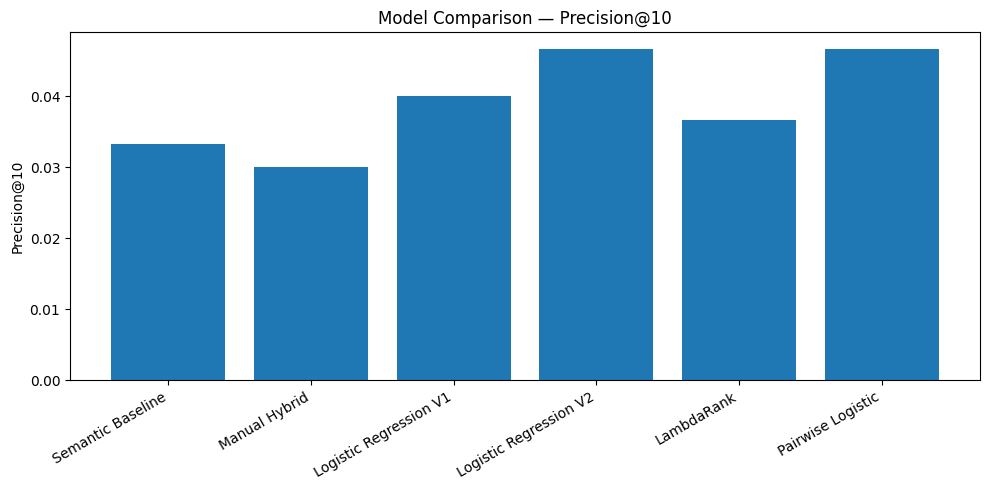

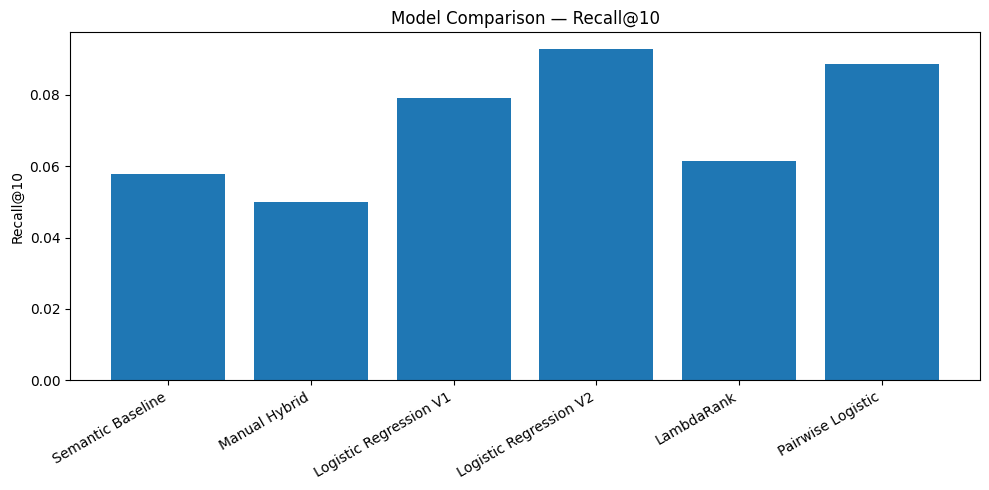

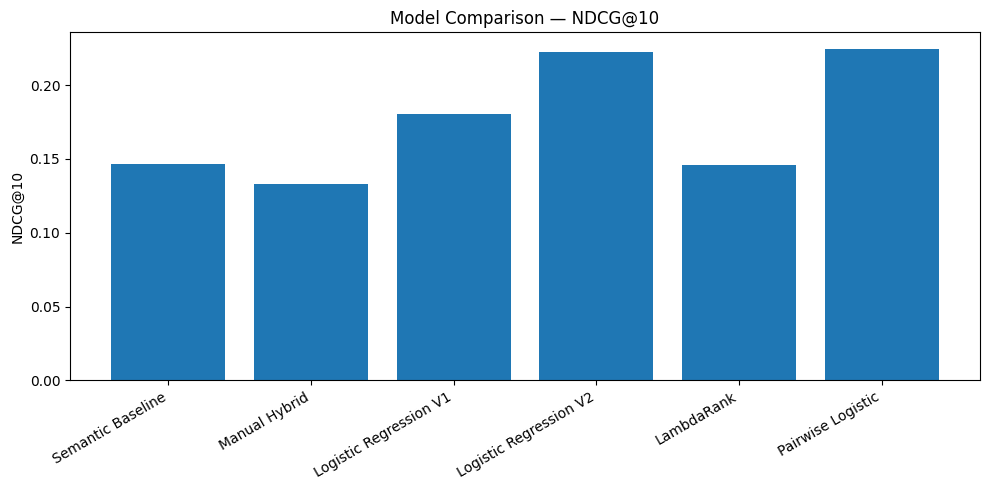

In [217]:
import matplotlib.pyplot as plt

metrics = ["Precision@10", "Recall@10", "NDCG@10"]

for metric in metrics:
    plt.figure(figsize=(10, 5))

    plt.bar(
        comparison["Model"],
        comparison[metric]
    )

    plt.title(f"Model Comparison — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 13. Final Project Summary

### Objective
Build an end-to-end NLP system for matching resumes to job descriptions and ranking the most relevant candidates.

### Pipeline
Resume / Job Data
→ Text Processing
→ Sentence Embeddings
→ Semantic Retrieval
→ Candidate Feature Engineering
→ Learned Ranking
→ Explainability
→ LLM-Powered Explanation

### Final Champion Model
Logistic Regression V2

### Final Features
- semantic_score
- skill_score
- experience_score
- experience_gap
- seniority_score
- seniority_gap
- industry_score
- missing_must_have_count
- must_have_coverage
- nice_to_have_coverage
- exact_must_have_match_count
- skill_count

### Final Validation Results
- Precision@10: 0.0467
- Recall@10: 0.0929
- NDCG@10: 0.2228
- MRR@10: 0.1619
- MAP@10: 0.0342

### Key Result
The final system combines semantic similarity with structured candidate-job features to produce a ranked list of candidates and provide interpretable matching information.

In [218]:
# Final Demo

demo_job_id = "J_002480"

demo_results = get_final_ranking(
    job_id=demo_job_id,
    top_k=10
)

demo_results

,Rank,Resume ID,Match Score,Role,Seniority,Industry,Years Experience,Must-Have Coverage,Matched Skills,Missing Skills
0,1,R_007142,97.13,Customer Success Associate,Mid,E-commerce,3,100.0,"escalations, customer satisfaction, root cause...",None
1,2,R_006753,96.96,Customer Success Associate,Mid,Gaming,3,100.0,"escalations, customer satisfaction, root cause...",None
2,3,R_000416,96.73,Customer Success Associate,Junior,Gaming,0,100.0,"escalations, customer satisfaction, root cause...",None
3,4,R_006338,96.24,Customer Support Specialist,Junior,Retail,0,100.0,"escalations, customer satisfaction, root cause...",None
4,5,R_002273,96.23,Customer Success Associate,Junior,Cybersecurity,0,100.0,"escalations, customer satisfaction, root cause...",None
5,6,R_007791,96.17,Customer Success Associate,Junior,Cybersecurity,1,100.0,"escalations, customer satisfaction, root cause...",None
6,7,R_005100,96.08,Customer Success Associate,Mid,Retail,6,100.0,"escalations, customer satisfaction, root cause...",None
7,8,R_003528,95.94,Customer Support Specialist,Mid,Cybersecurity,4,100.0,"escalations, customer satisfaction, root cause...",None
8,9,R_008074,95.92,Customer Support Specialist,Mid,Gaming,6,100.0,"escalations, customer satisfaction, root cause...",None
9,10,R_008241,95.37,Technical Support Specialist,Junior,Cybersecurity,2,100.0,"escalations, customer satisfaction, root cause...",None


In [219]:
import joblib

# Save Final Model
joblib.dump(
    final_ranker,
    "final_resume_job_ranker.pkl"
)

# Save Feature Configuration
joblib.dump(
    final_features,
    "final_features.pkl"
)

print("Final model saved successfully.")
print("Feature configuration saved successfully.")

Final model saved successfully.
Feature configuration saved successfully.
